# Electron Equivalent Modeling
Based on the methodologies from Postma (1991) and Juncher Jørgensen (2009).

## Calculations & Stoichiometry
We convert measured concentrations (mg/L) into molar concentrations (mmol/L) by dividing by their respective molar mass. Then, we multiply by the absolute number of electrons transferred in their respective half-reactions to obtain Electron Equivalents (mEq/L).

**Half-Reactions & Electron Equivalents:**
* **Nitrate ($NO_3^-$):** $NO_3^- \rightarrow \frac{1}{2} N_2$ (+5 $e^-$) $\rightarrow$ Eq = 5 $\times [NO_3^-]$
* **Sulfate ($SO_4^{2-}$):** Pyrite oxidation produces $SO_4^{2-}$. $S_{FeS2} \rightarrow SO_4^{2-}$ (-7 $e^-$) $\rightarrow$ Eq = 7 $\times [SO_4^{2-}]$
* **Manganese ($Mn^{2+}$):** $MnO_2 \rightarrow Mn^{2+}$ (+2 $e^-$) $\rightarrow$ Eq = 2 $\times [Mn^{2+}]$
* **Iron ($Fe^{2+}$):** $FeOOH \rightarrow Fe^{2+}$ (+1 $e^-$) $\rightarrow$ Eq = 1 $\times [Fe^{2+}]$
* **TIC ($CH_2O$ proxy):** $CH_2O \rightarrow CO_2$ (-4 $e^-$) $\rightarrow$ Eq = 4 $\times [TIC]$ (Assuming TIC measured as C, molar mass 12.011 g/mol)

## Filtering
Only boreholes that possess corresponding high-resolution redox data (from `Master_Redox.csv`) are plotted. This aligns exactly with the `Advanced_Plotting/basic_plotting.ipynb` inclusion criteria.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# --- SETTINGS ---
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

PLOT_PRIMARY_INTERFACE = True
PLOT_SECONDARY_INTERFACE = True
PLOT_FE_RATIO = True


In [2]:
# --- DATA LOADING & NORMALIZATION ---
path_geochem = '../Python_Redox_Geochemistry/Geochemistry/Master_Geochemistry.csv'
path_redox = '../Python_Redox_Geochemistry/Redox/Master_Redox.csv'
path_algo = '../Interface_Detection/Extracted_Advanced_Interfaces.csv'

encodings = ['utf-8-sig', 'utf-8', 'latin1', 'cp1252']
df_geochem, df_redox = None, None

for enc in encodings:
    try:
        if df_geochem is None:
            df_geochem = pd.read_csv(path_geochem, encoding=enc)
            df_geochem.columns = df_geochem.columns.str.strip().str.replace('^ï»¿', '', regex=True)
        if df_redox is None:
            df_redox = pd.read_csv(path_redox, encoding=enc)
            df_redox.columns = df_redox.columns.str.strip().str.replace('^ï»¿', '', regex=True)
    except Exception:
        continue

# Normalize IDs
def normalize_id(row, source):
    loop = str(row['LOOPNr']).strip().upper()
    raw_id = str(row['ID']).strip()

    if source == 'Redox':
        norm = re.sub(r'[a-z]$', '', raw_id, flags=re.IGNORECASE)
        if loop == 'DEMO':
            if norm.isdigit():
                norm = f"D{norm}"
        if loop == 'LOOP4':
            norm = norm.replace('Geological Window-', 'GeoW-')
            norm = norm.replace('interglacial sand-', 'IS-')
            norm = norm.replace('meltwater sand-', 'MS-')
            norm = norm.replace('Til layer-', 'TL-')
        return norm

    elif source == 'Geochem':
        if loop in ['LOOP2', 'LOOP3', 'LOOP6']:
            norm = re.sub(r'^P', '', raw_id)
            return norm
        return raw_id

df_geochem['Normalized_ID'] = df_geochem.apply(lambda r: normalize_id(r, 'Geochem'), axis=1)
df_redox['Normalized_ID'] = df_redox.apply(lambda r: normalize_id(r, 'Redox'), axis=1)

# Load Algo interfaces
try:
    df_algo = pd.read_csv(path_algo)
    df_algo['Norm_ID'] = df_algo.apply(lambda row: normalize_id(row, 'Redox'), axis=1)
    df_interfaces = df_algo.groupby(['LOOPNr', 'Norm_ID'])[['Main_Drop_Z', 'Sec_Drop_Z']].mean().reset_index()
except Exception as e:
    print(f"Error loading Algo_2026_Results.csv: {e}")
    df_interfaces = pd.DataFrame(columns=['LOOPNr', 'Norm_ID', 'Main_Drop_Z', 'Sec_Drop_Z'])

# FILTER: Only keep boreholes present in df_redox
valid_keys = df_redox[['LOOPNr', 'Normalized_ID']].drop_duplicates()
valid_set = set(zip(valid_keys['LOOPNr'], valid_keys['Normalized_ID']))

df_geochem['is_valid'] = df_geochem.apply(lambda r: (r['LOOPNr'], r['Normalized_ID']) in valid_set, axis=1)
df_geochem = df_geochem[df_geochem['is_valid']].copy()

# Keep relevant columns
columns_needed = ['LOOPNr', 'Normalized_ID', 'Depth (m)', 'TIC [mg/L]', 'NO₃⁻ [mg/L]', 'SO₄²⁻ [mg/L]', 'Fe²⁺ [mg/L]', 'Mn²⁺ [mg/L]', 'Fe(II)/Fe(total) [-]']
df_sub = df_geochem[[c for c in columns_needed if c in df_geochem.columns]].copy()

# Ensure numeric
for col in ['Depth (m)', 'TIC [mg/L]', 'NO₃⁻ [mg/L]', 'SO₄²⁻ [mg/L]', 'Fe²⁺ [mg/L]', 'Mn²⁺ [mg/L]', 'Fe(II)/Fe(total) [-]']:
    if col in df_sub.columns:
        df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
        
df_sub = df_sub.dropna(subset=['Depth (m)'])


In [3]:
# --- ELECTRON EQUIVALENT CONVERSION ---
# Conversion factors (mg/L -> mmol/L -> mEq/L)
MOLAR_MASS = {
    'TIC': 12.011,  # Carbon
    'NO₃⁻': 62.004,
    'SO₄²⁻': 96.06,
    'Fe²⁺': 55.845,
    'Mn²⁺': 54.938
}

E_TRANSFER = {
    'TIC': 4,       # CH2O -> CO2 (4e-)
    'NO₃⁻': 5,      # NO3- -> 1/2 N2 (5e-)
    'SO₄²⁻': 7,     # Pyrite oxidation -> SO4(2-) (7e-)
    'Fe²⁺': 1,      # FeOOH -> Fe2+ (1e-)
    'Mn²⁺': 2       # MnO2 -> Mn2+ (2e-)
}

for species, molar_mass in MOLAR_MASS.items():
    mg_l_col = f"{species} [mg/L]"
    meq_l_col = f"{species} [mEq/L]"
    
    if mg_l_col in df_sub.columns:
        # Convert mg/L to mmol/L, then multiply by e- transfer to get mEq/L
        df_sub[meq_l_col] = (df_sub[mg_l_col] / molar_mass) * E_TRANSFER[species]

meq_cols = [f"{s} [mEq/L]" for s in MOLAR_MASS.keys() if f"{s} [mg/L]" in df_sub.columns]


In [4]:
# --- COLOR DICTIONARY ---
# Adopting colors matching basic_plotting.ipynb logic
COLOR_MAP = {
    'TIC [mEq/L]': '#333333',     # Dark Gray/Black for TIC
    'NO₃⁻ [mEq/L]': '#F20B0B',    # Red
    'SO₄²⁻ [mEq/L]': '#1b9e77',   # Green
    'Fe²⁺ [mEq/L]': '#d95f02',    # Brown/Orange
    'Mn²⁺ [mEq/L]': '#7570b3'     # Purple
}


<>:289: SyntaxWarning: invalid escape sequence '\D'
<>:289: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_208636/2909152015.py:289: SyntaxWarning: invalid escape sequence '\D'
  ax3.set_xlabel("Ratio ($\Delta$Donor / |$\Delta$NO₃⁻|)", fontweight='bold')


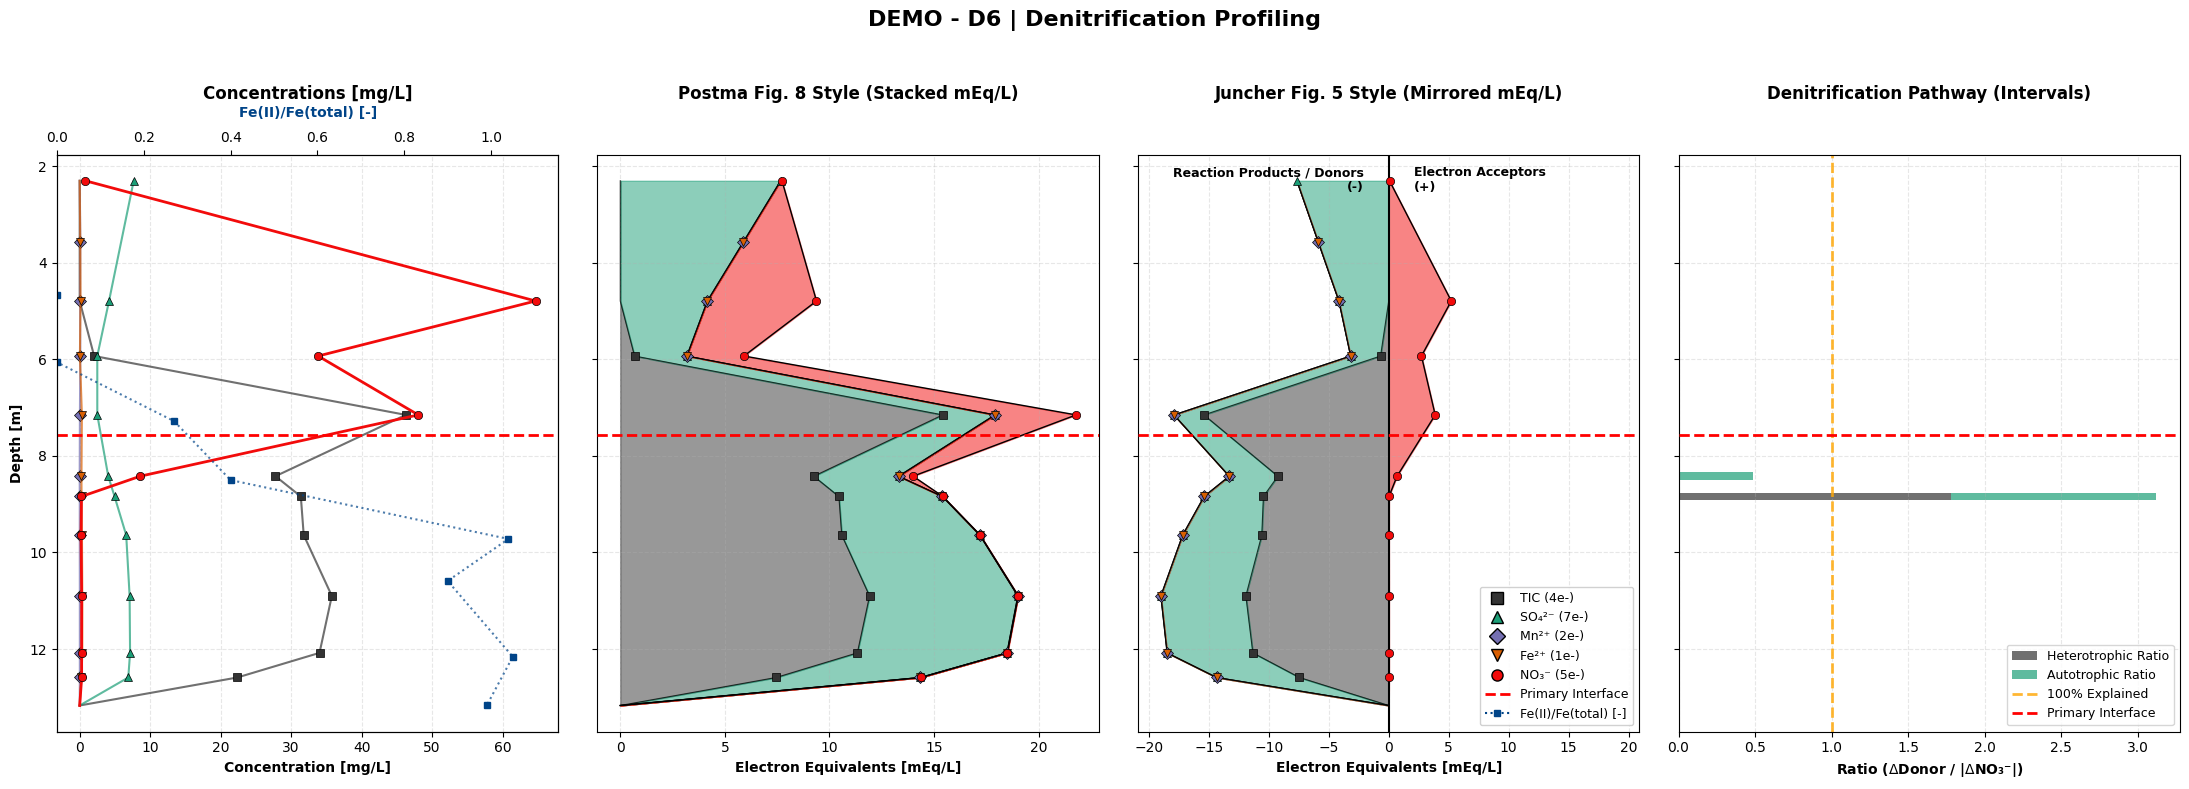

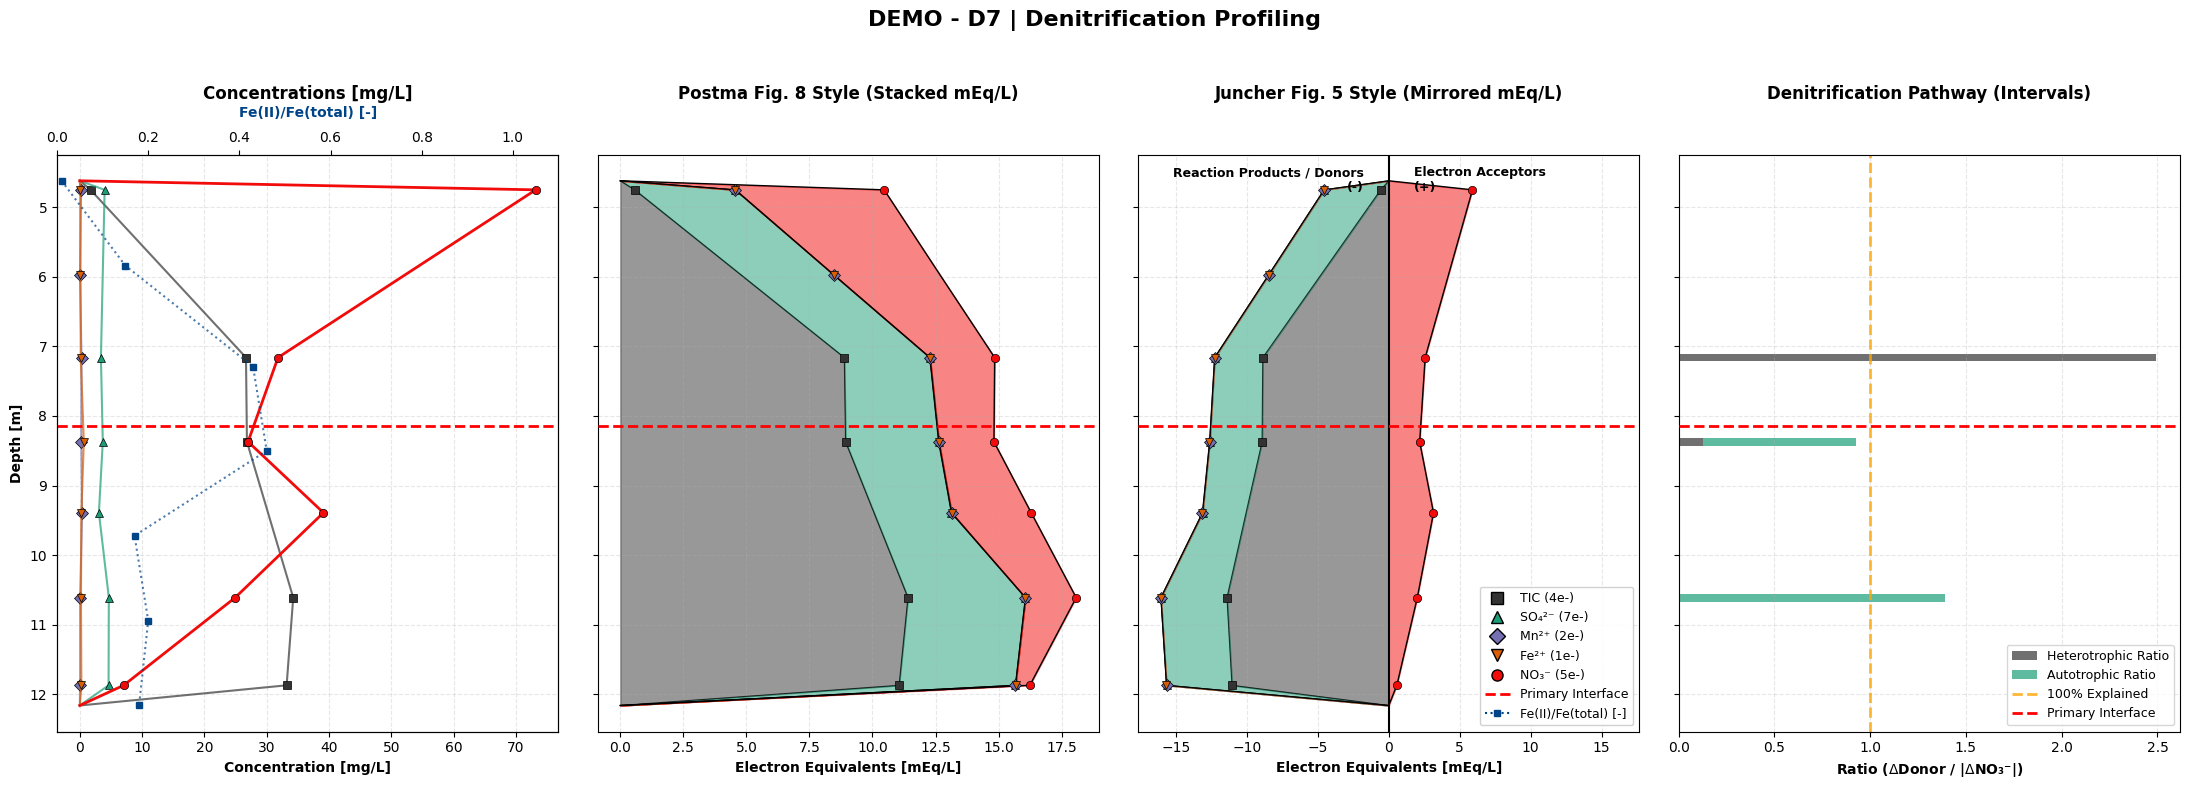

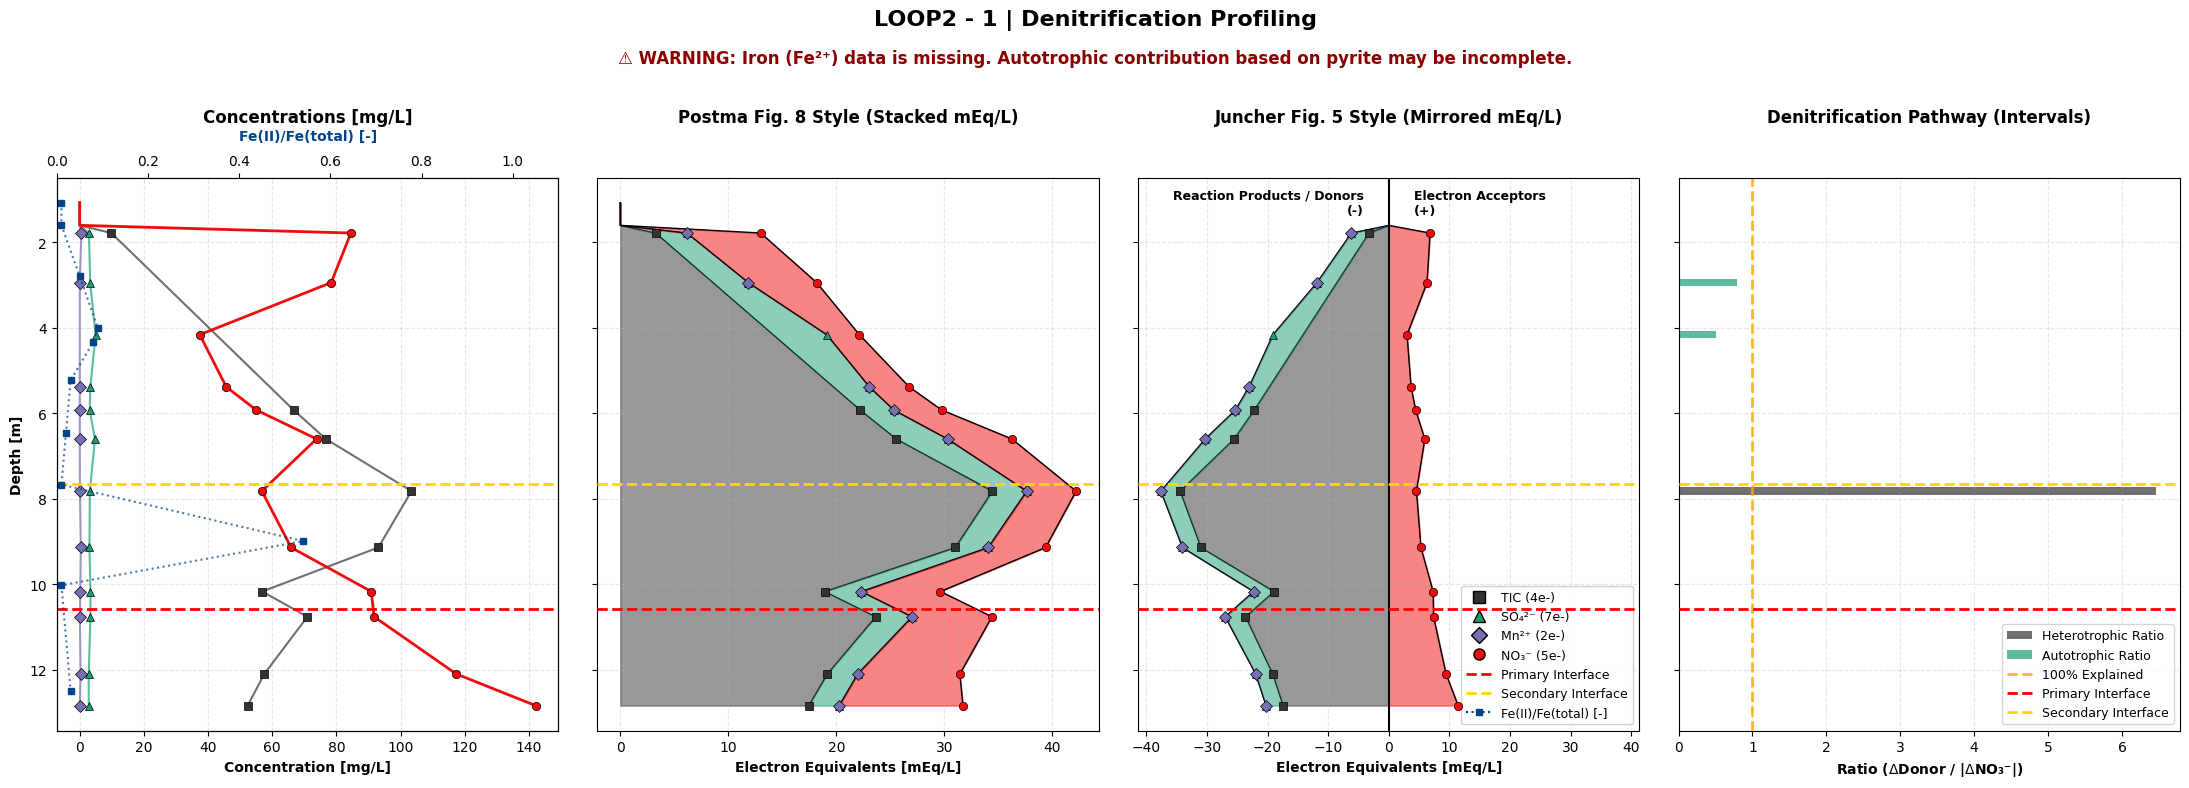

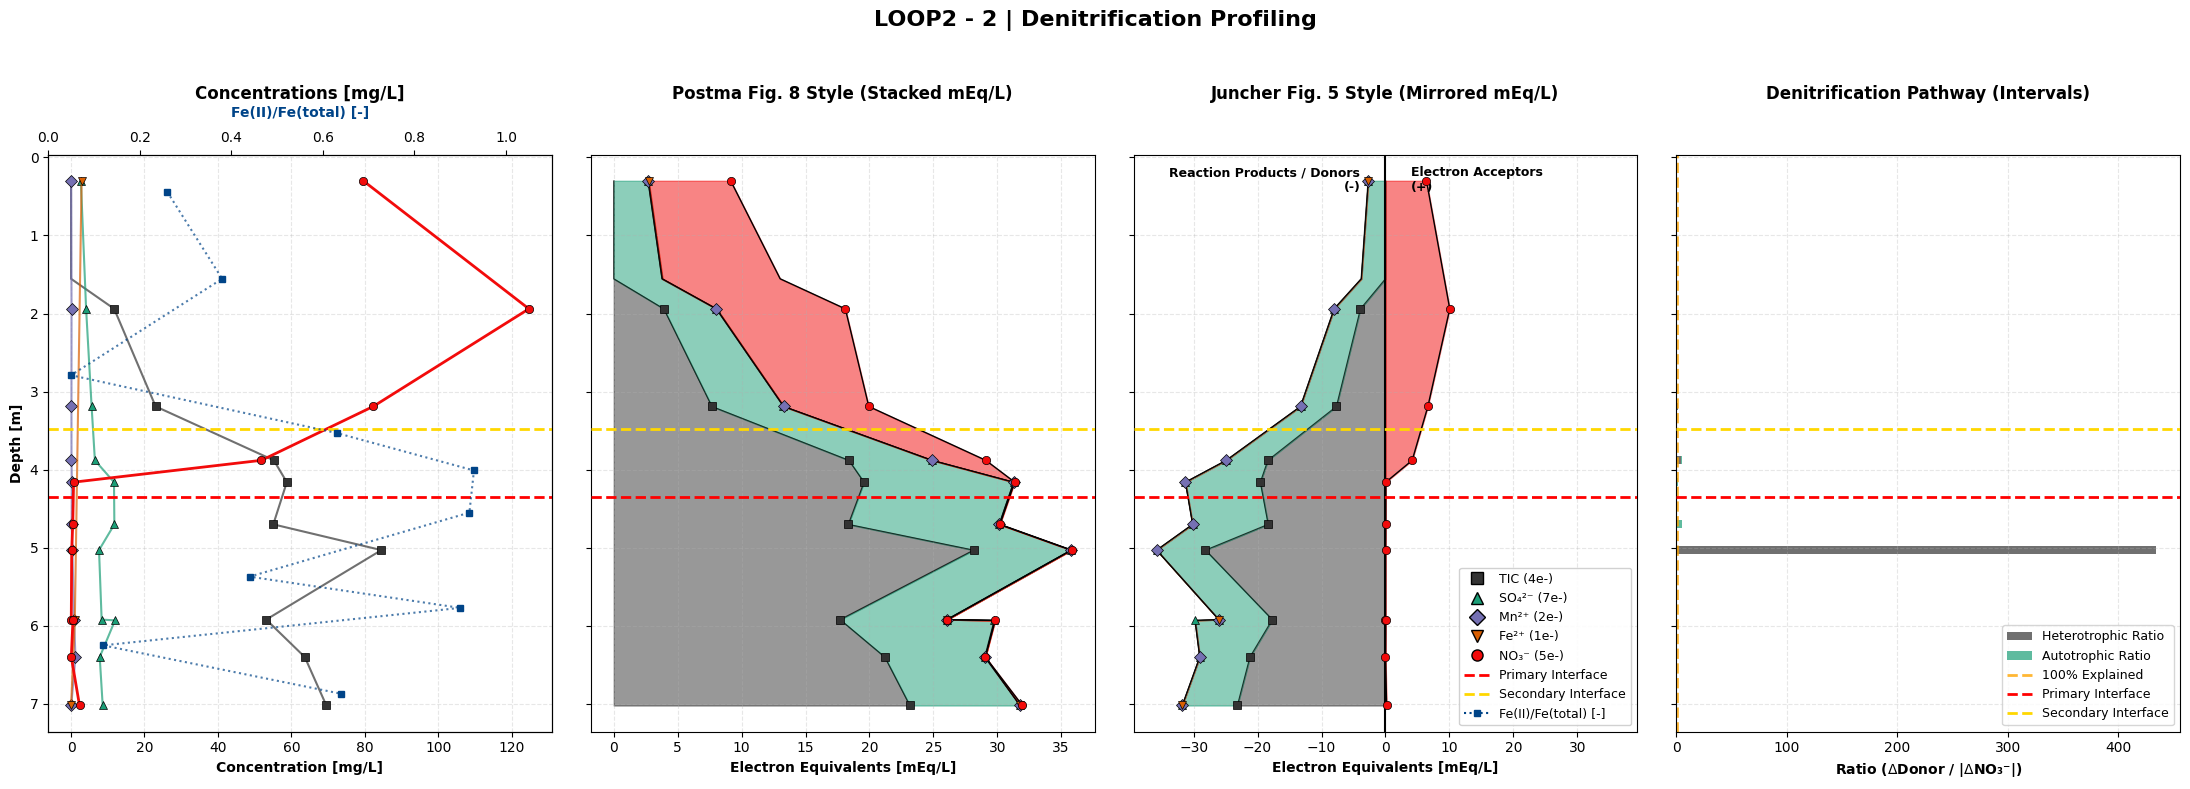

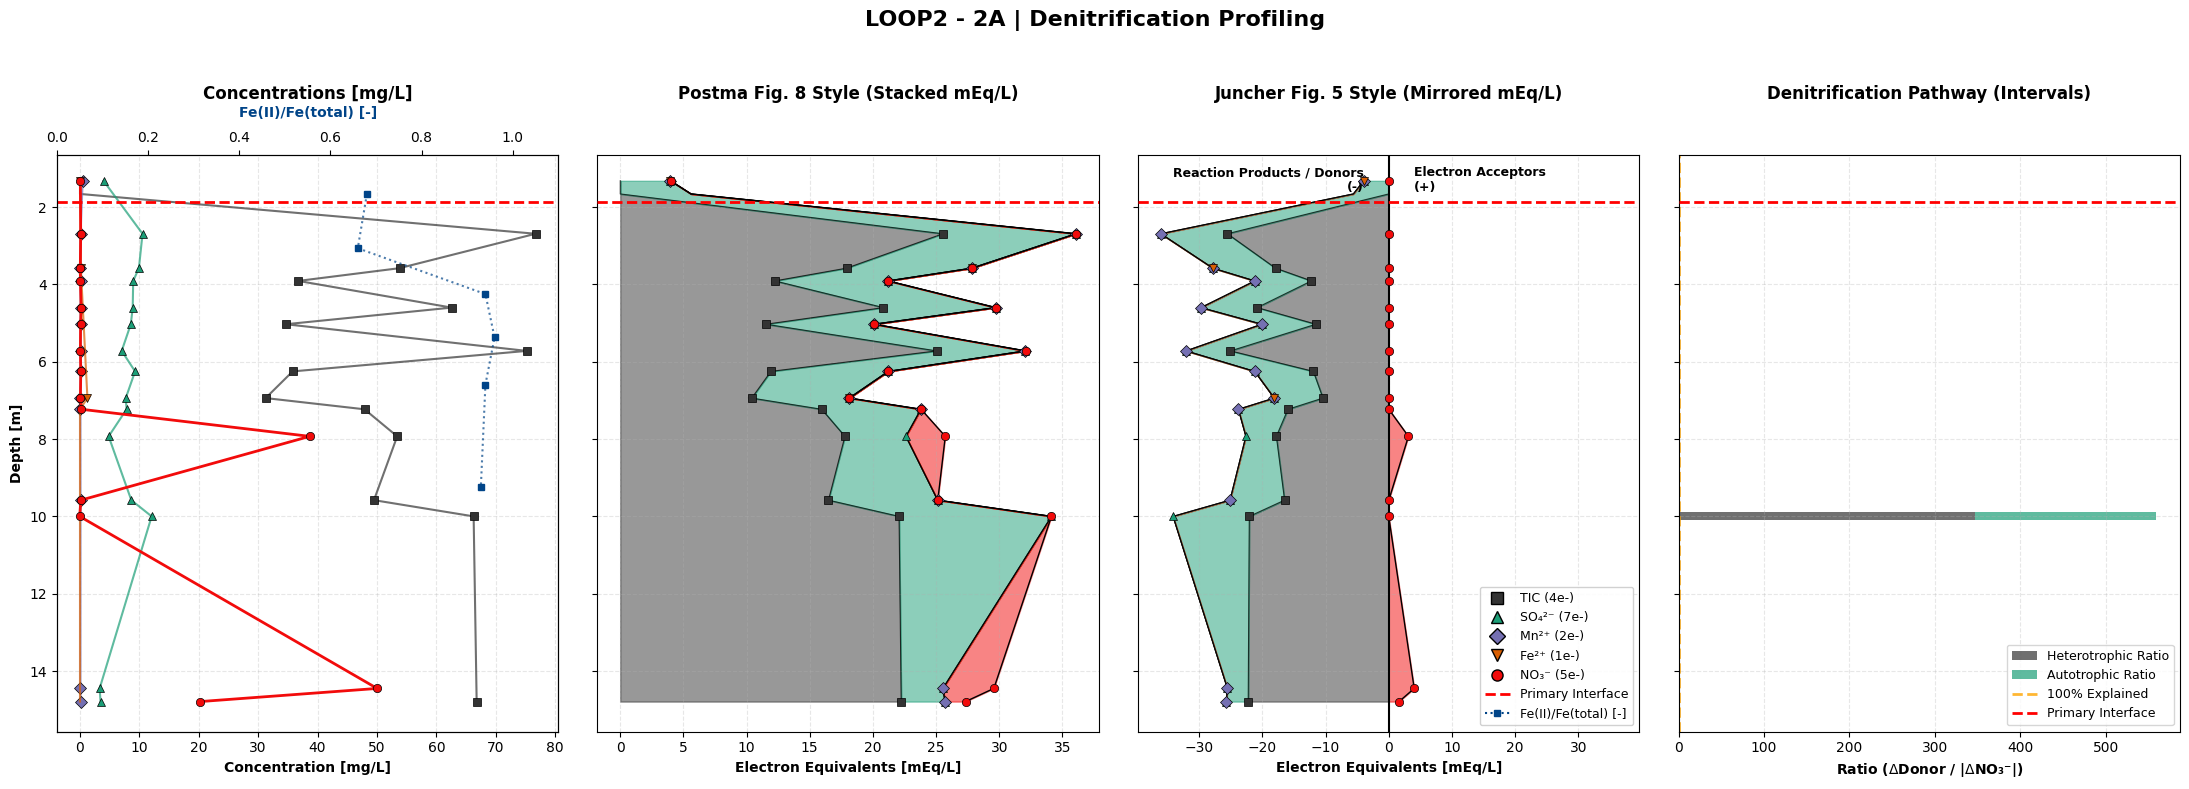

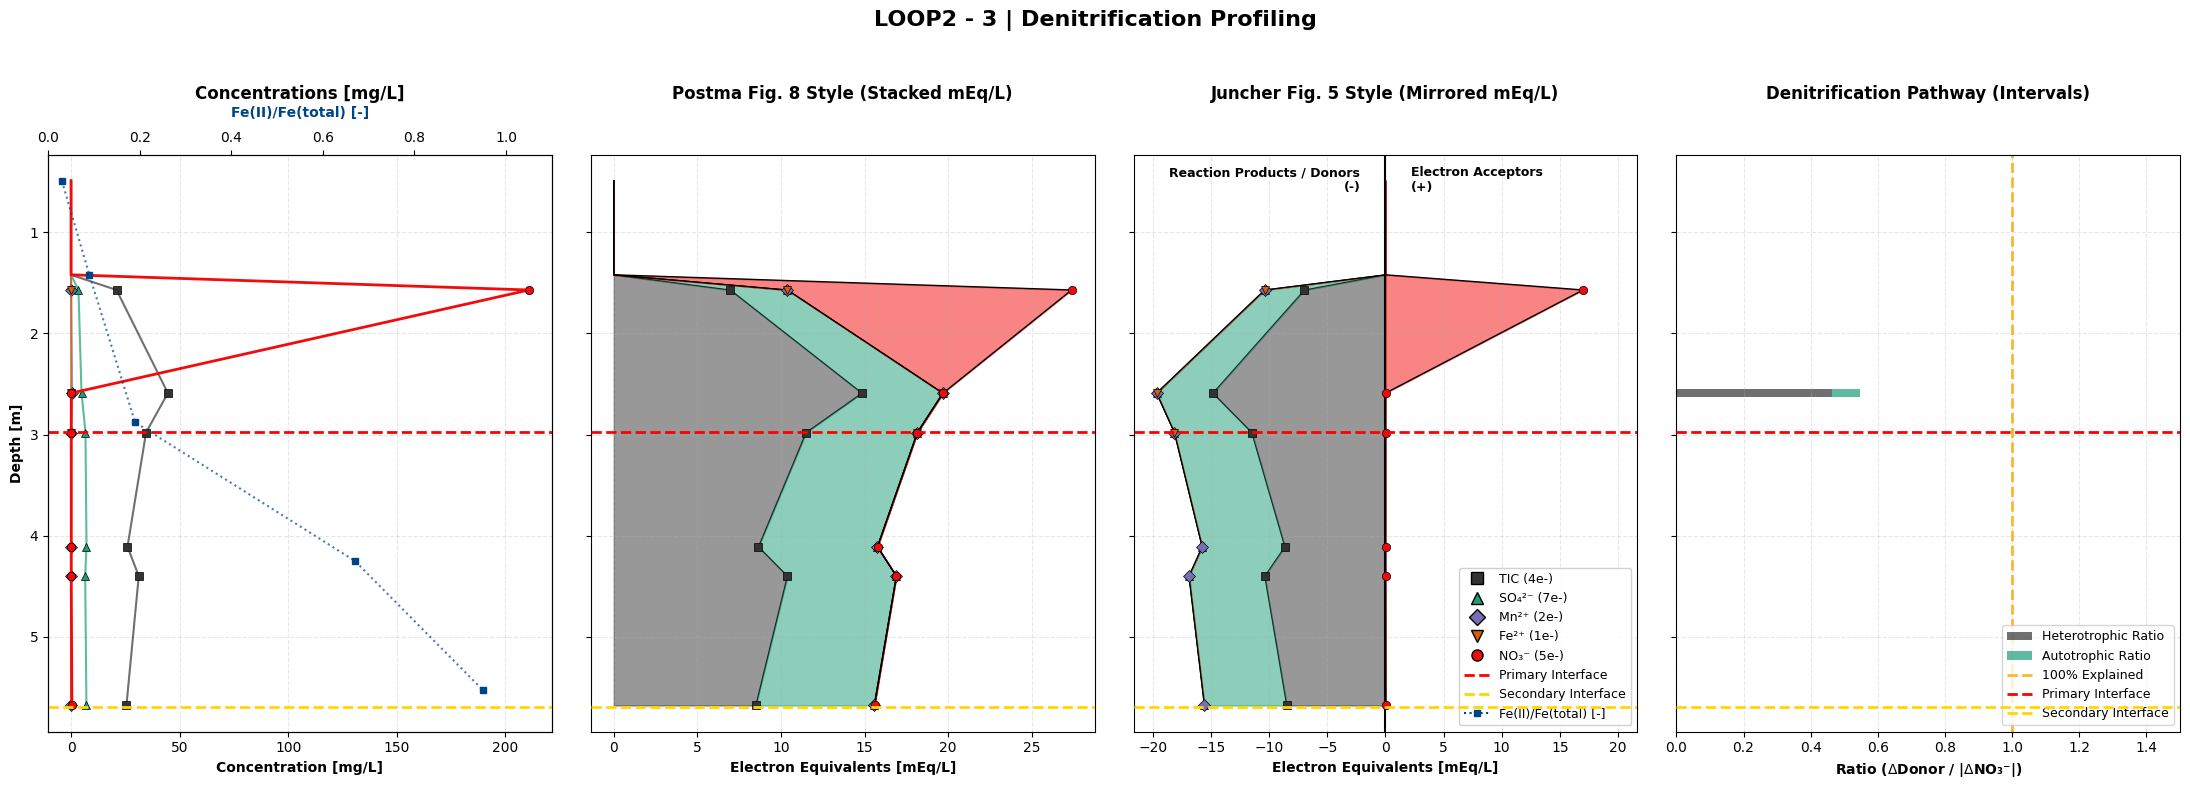

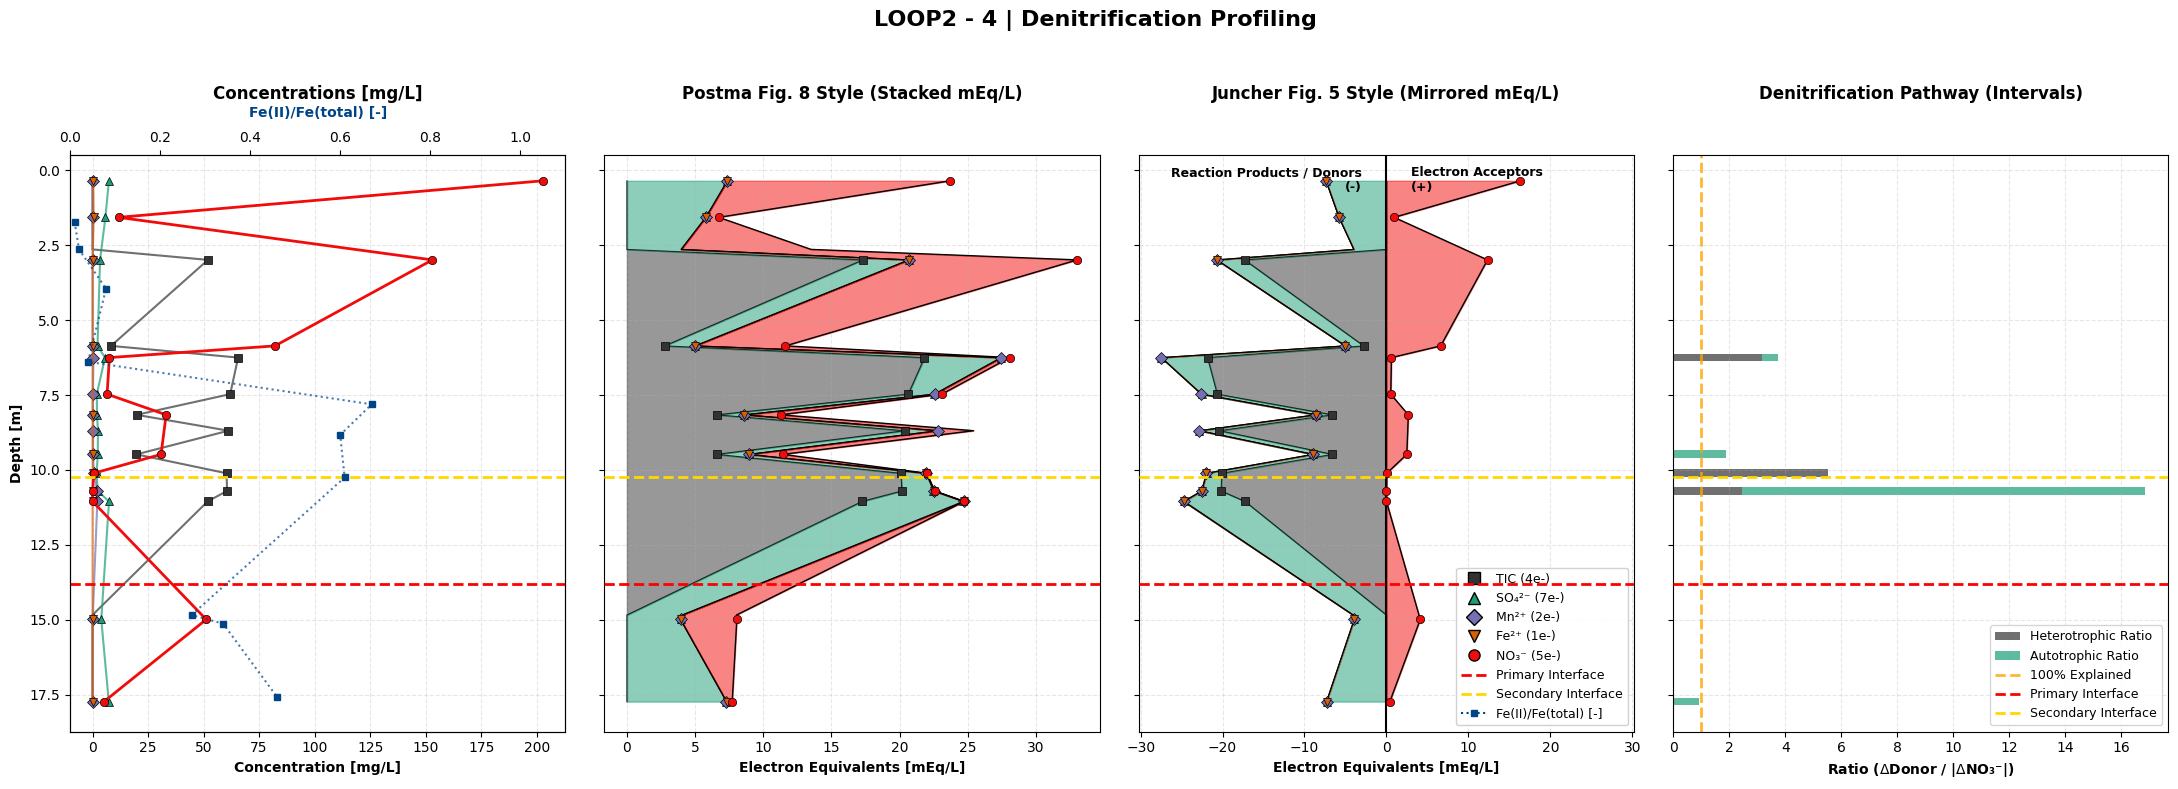

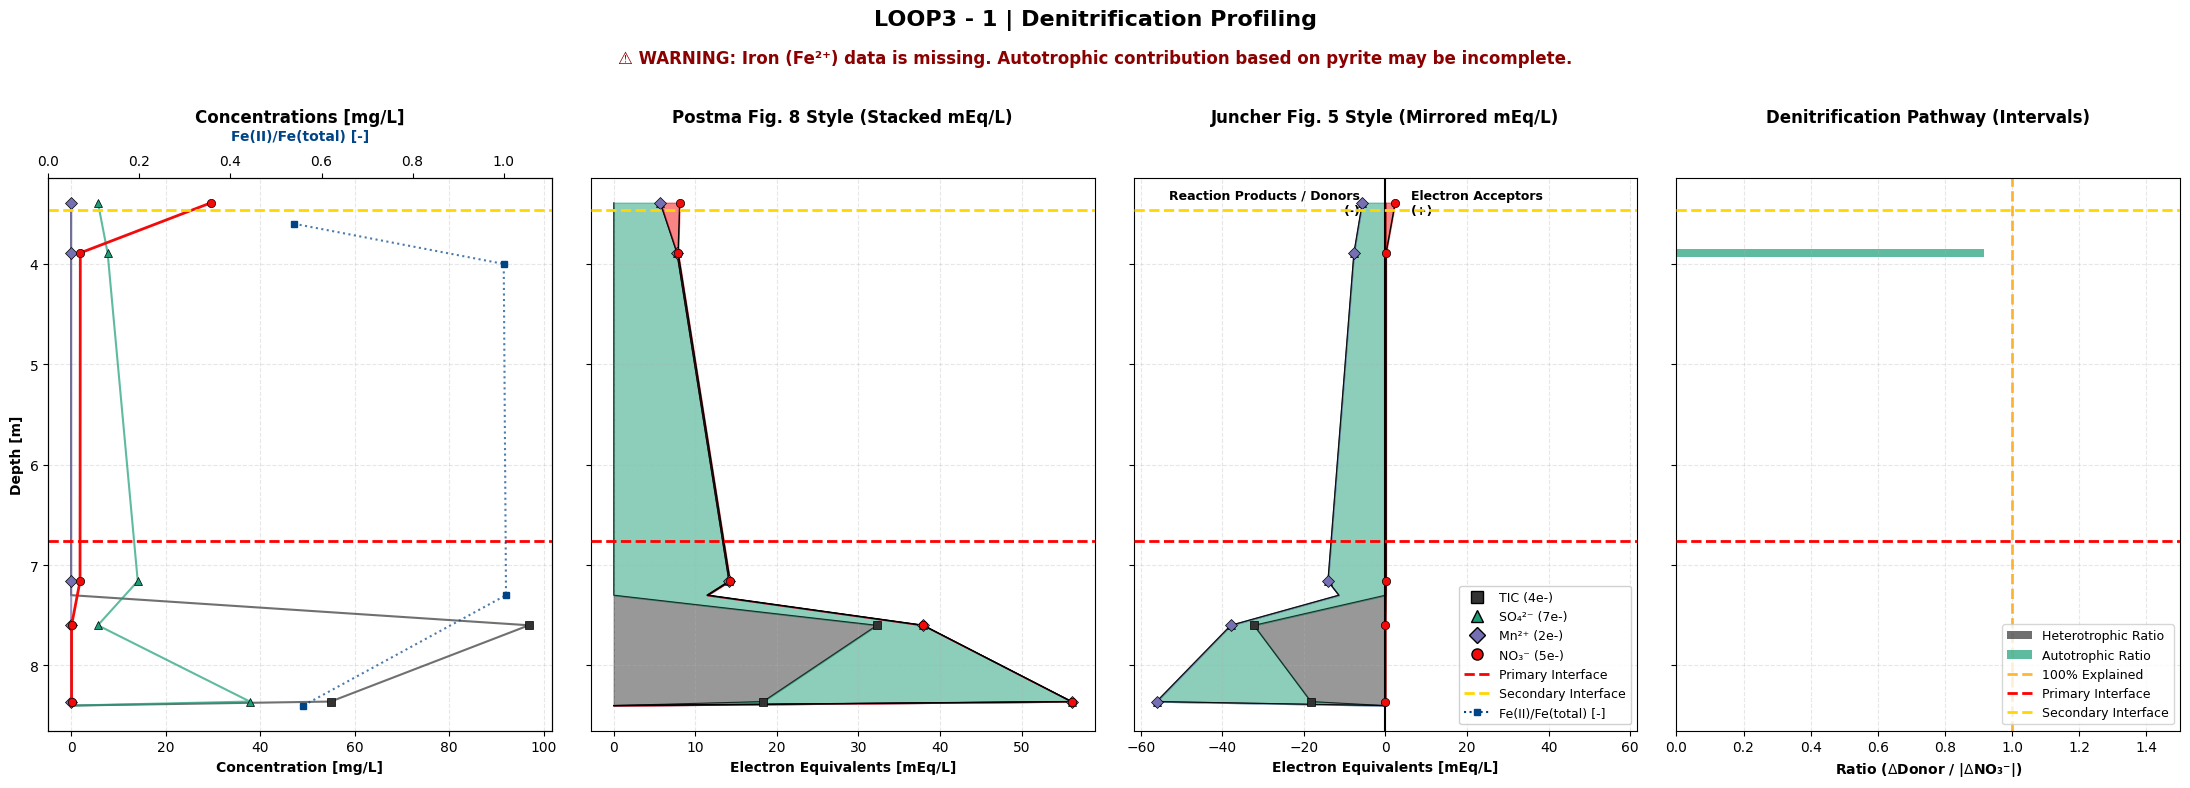

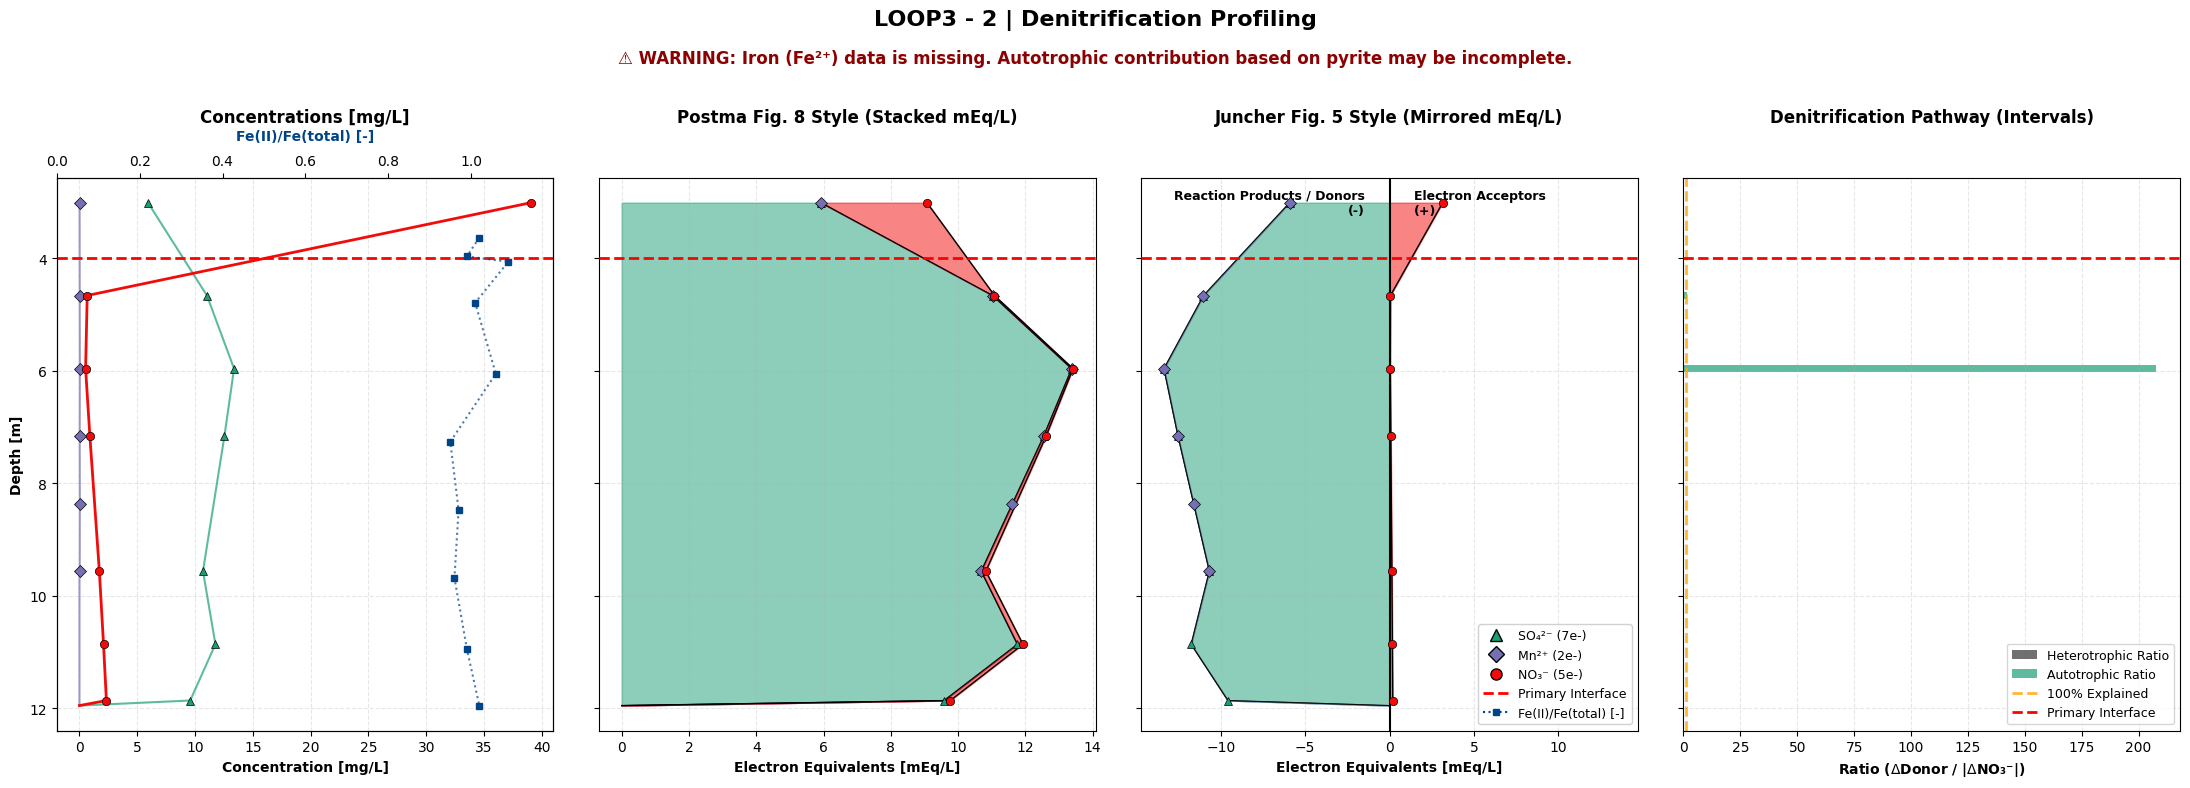

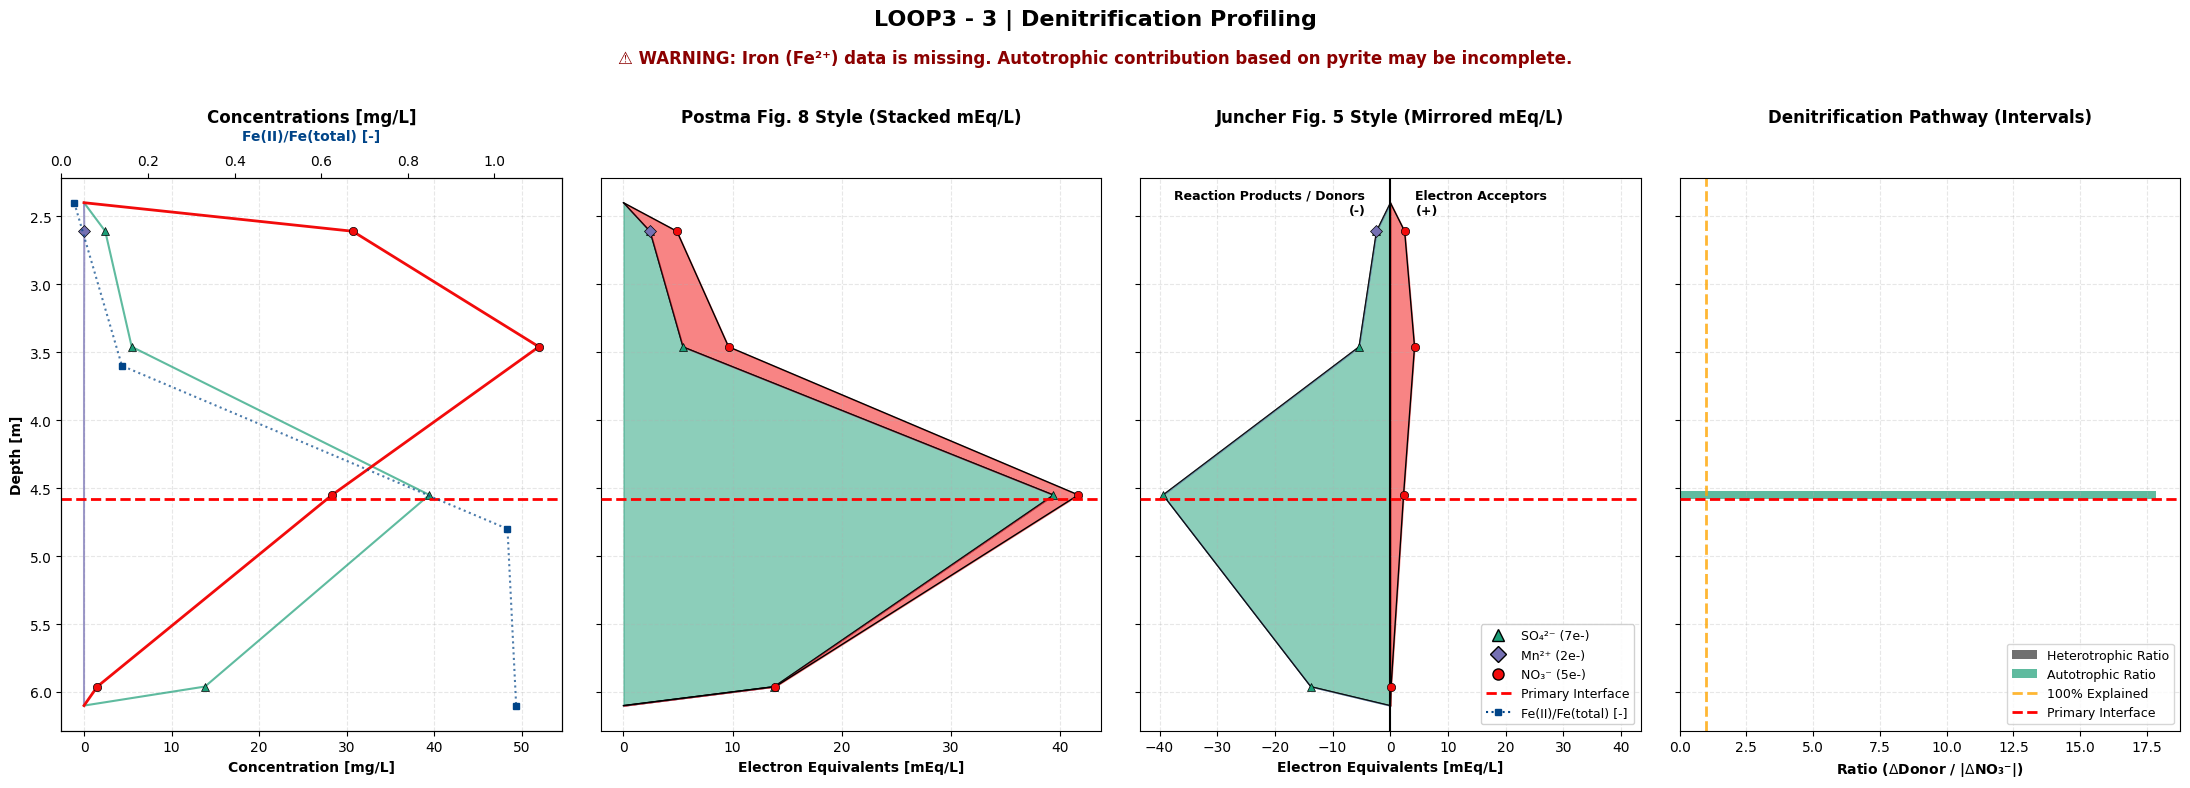

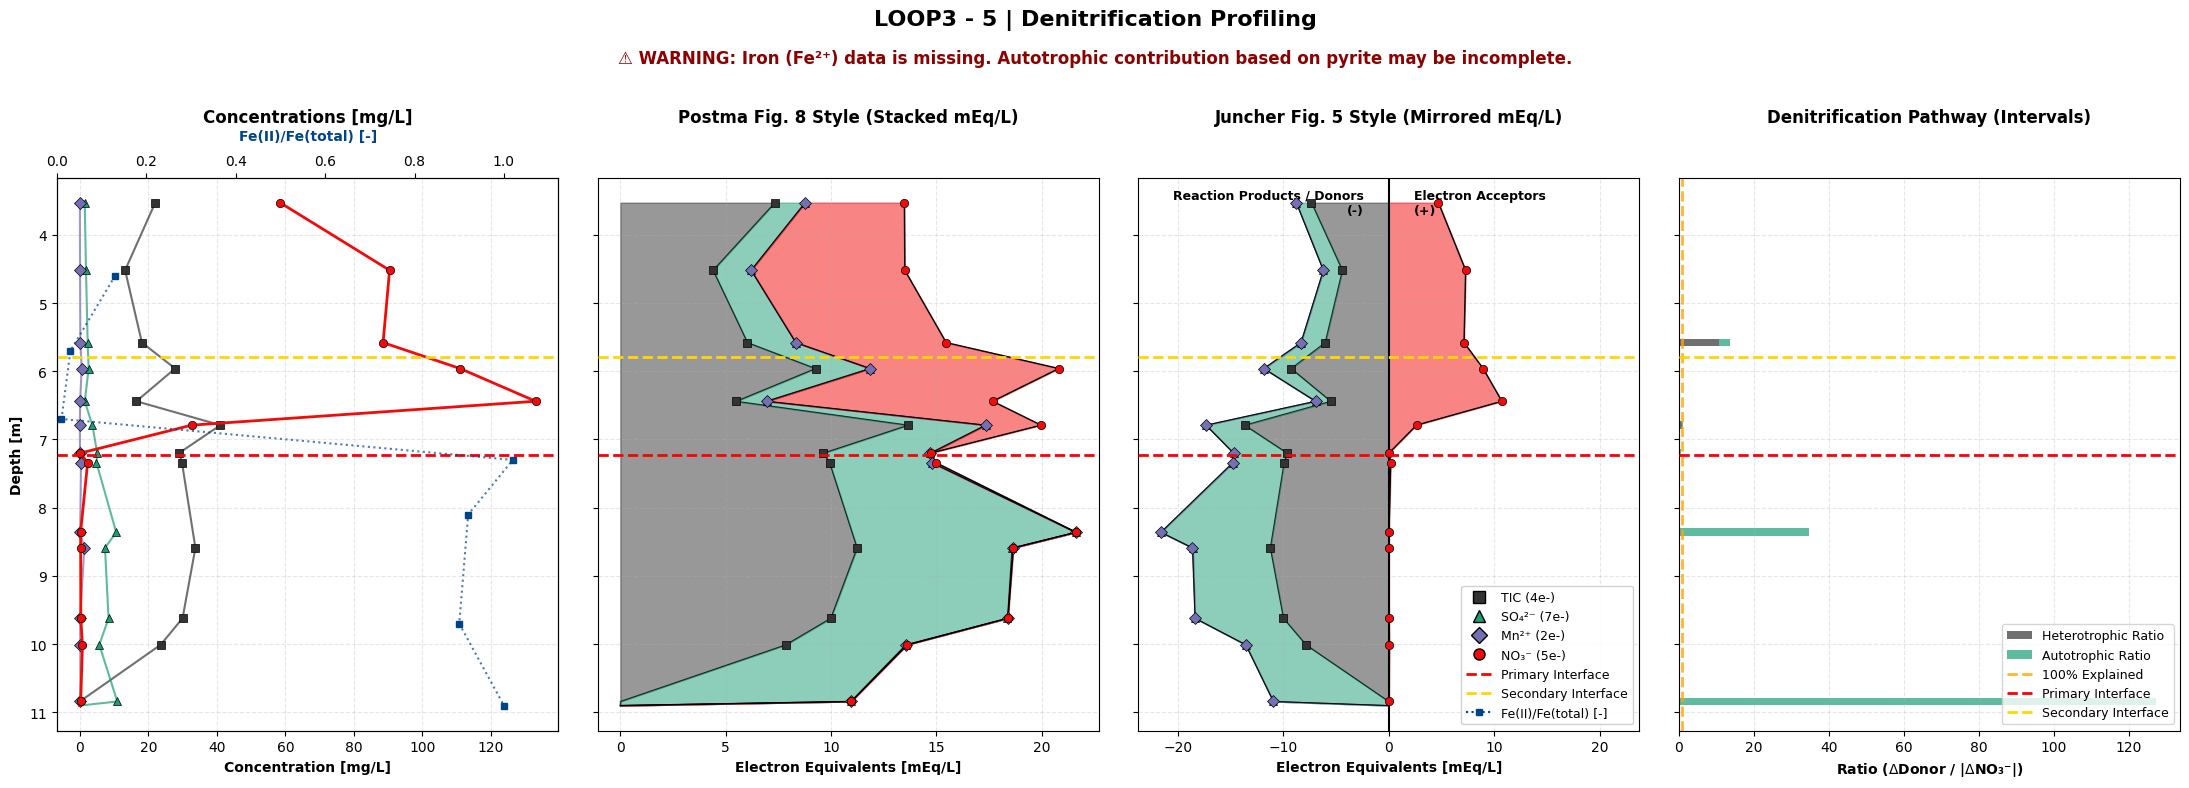

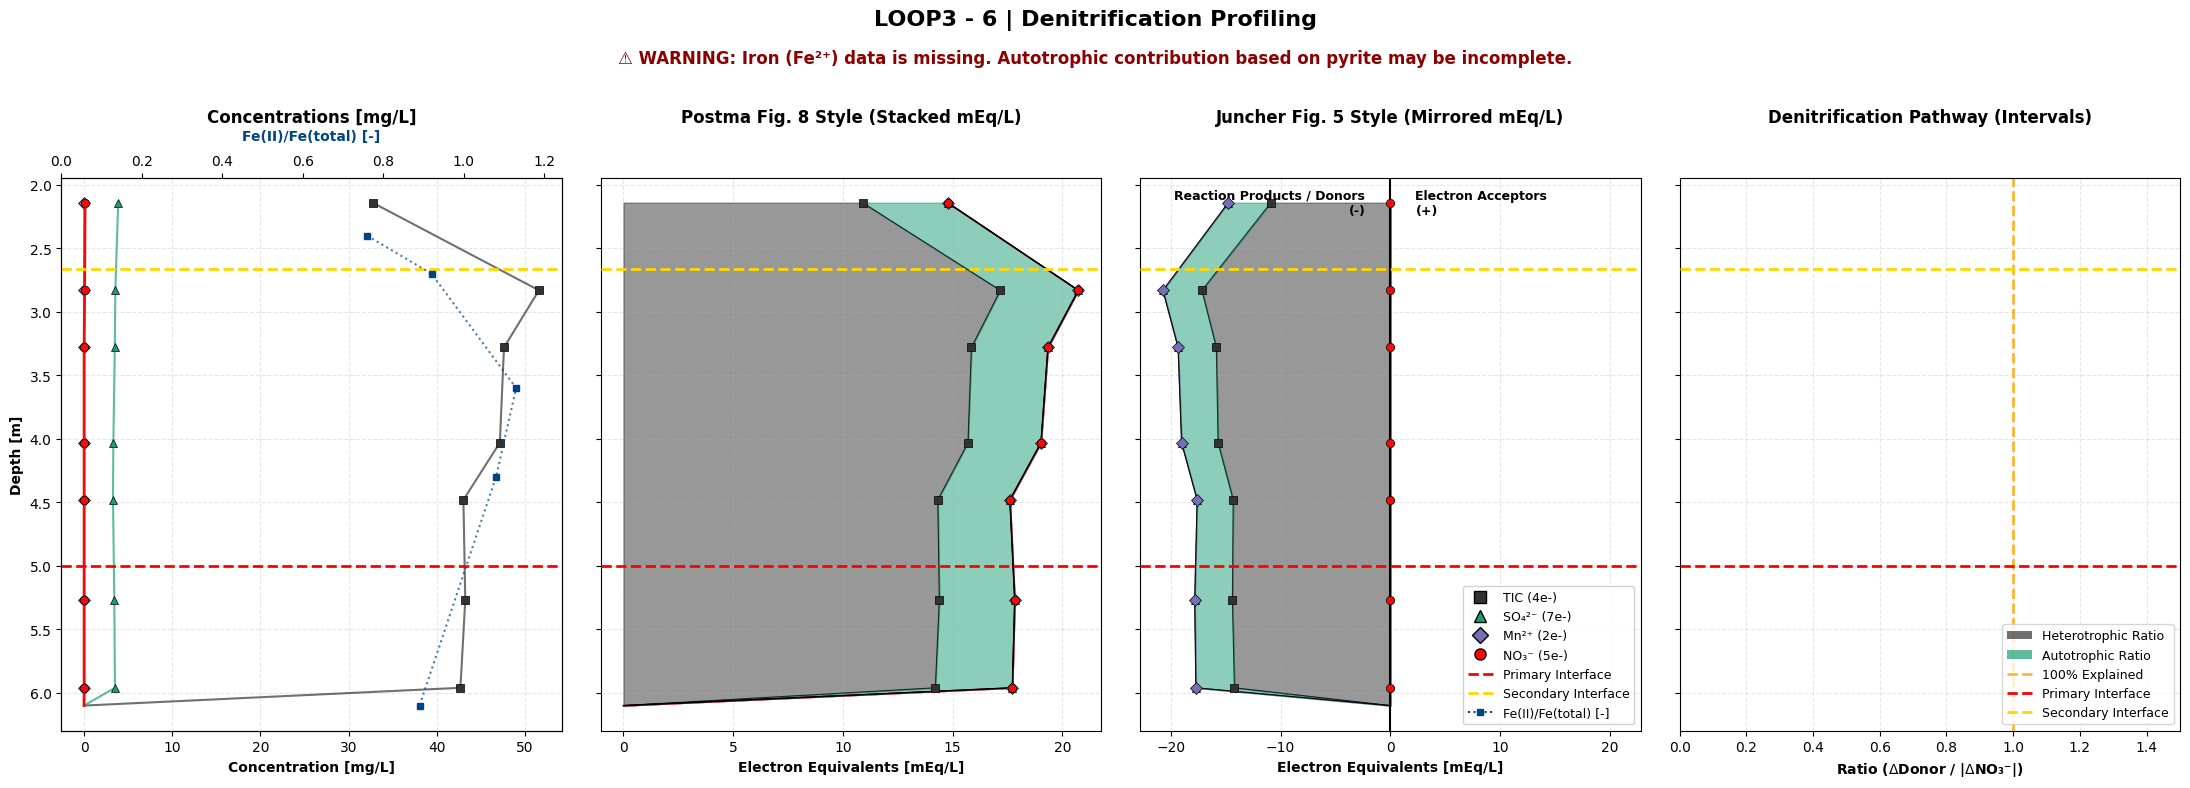

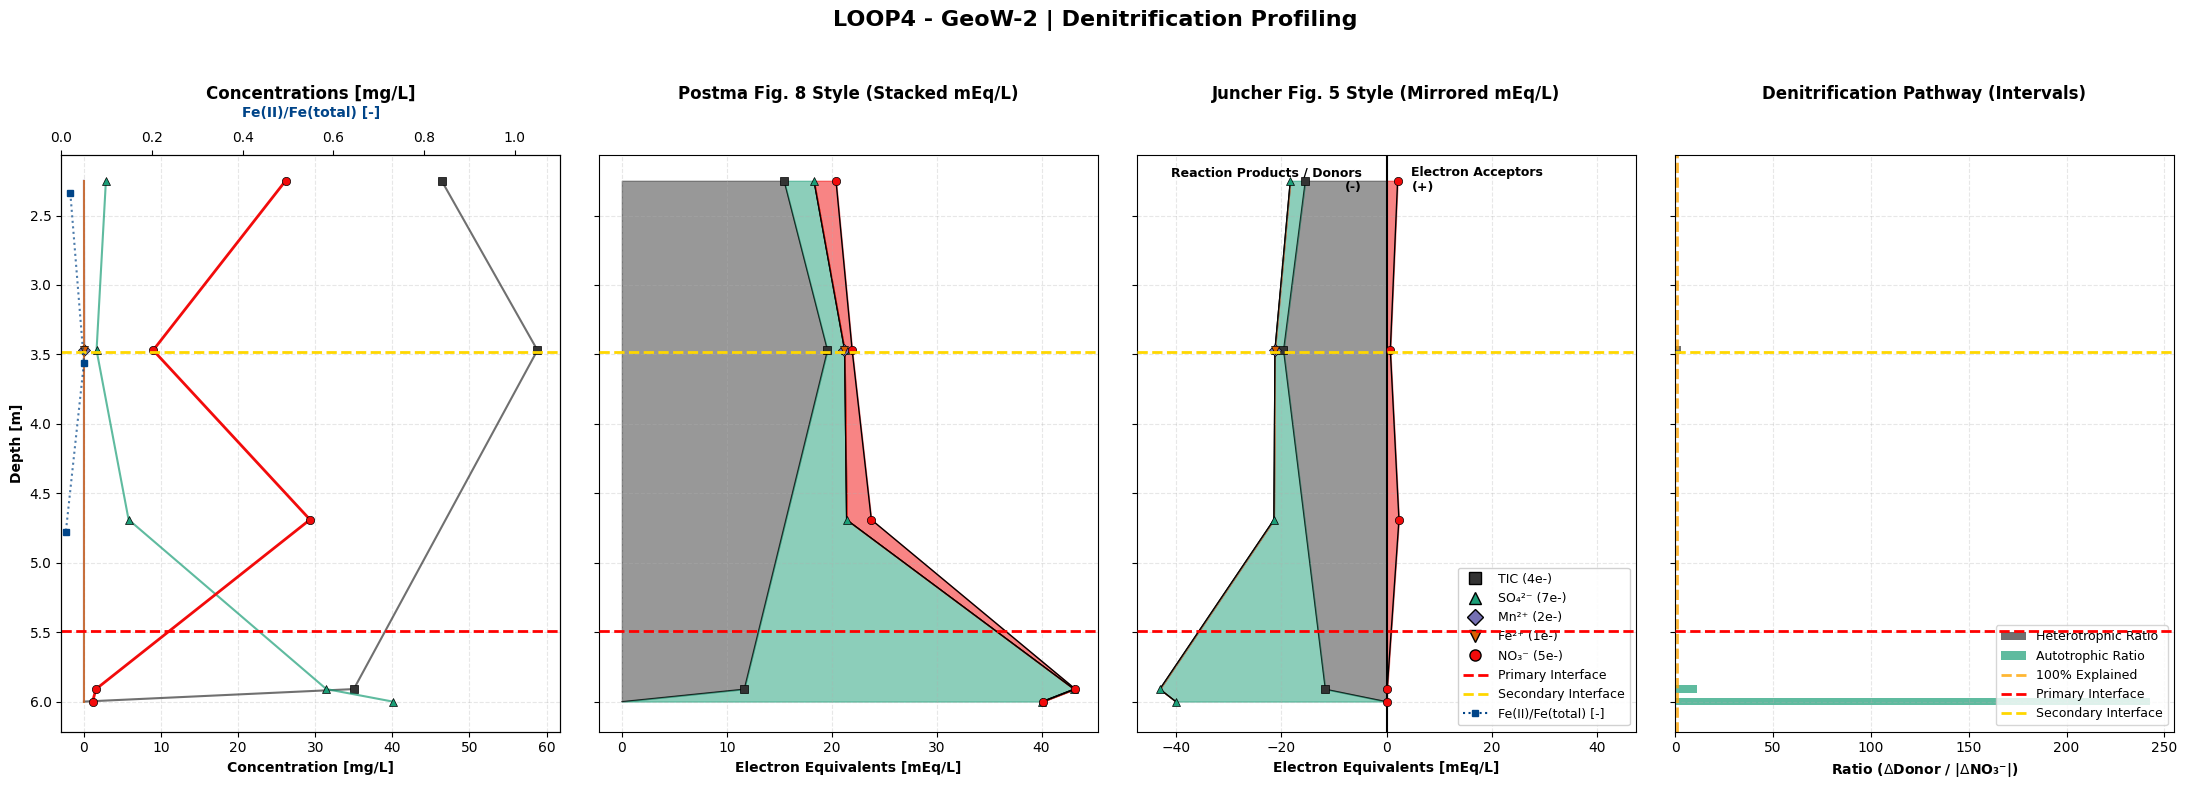

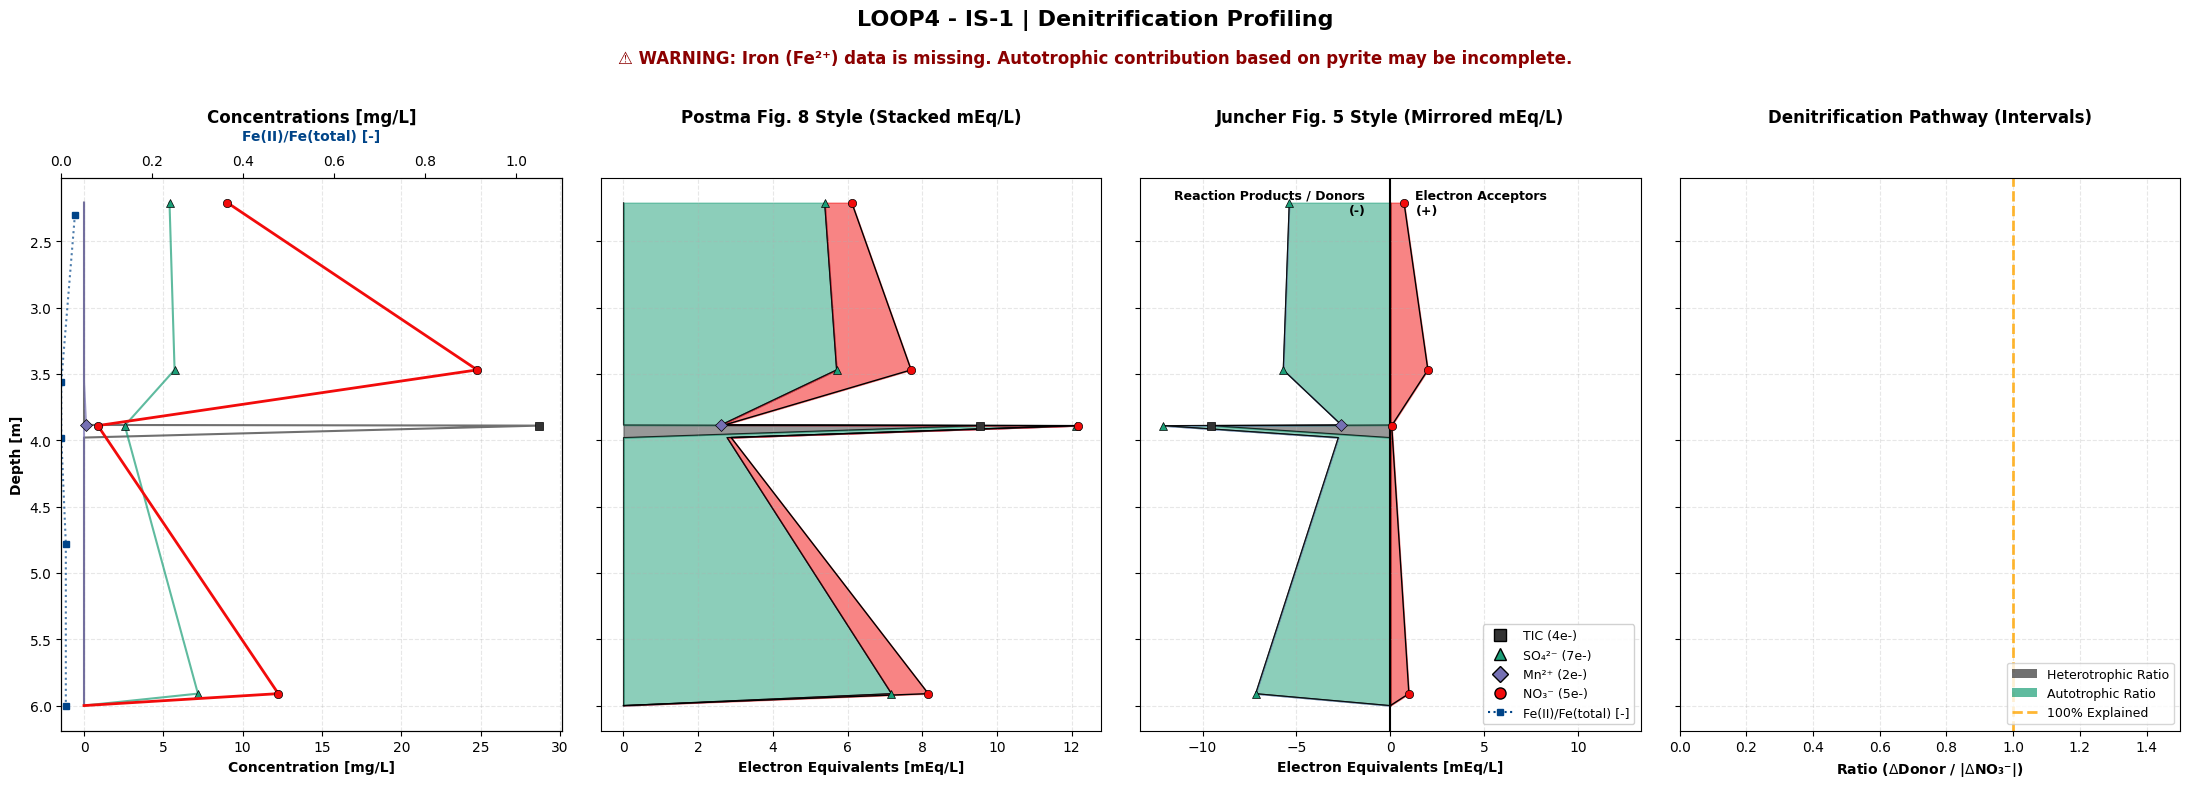

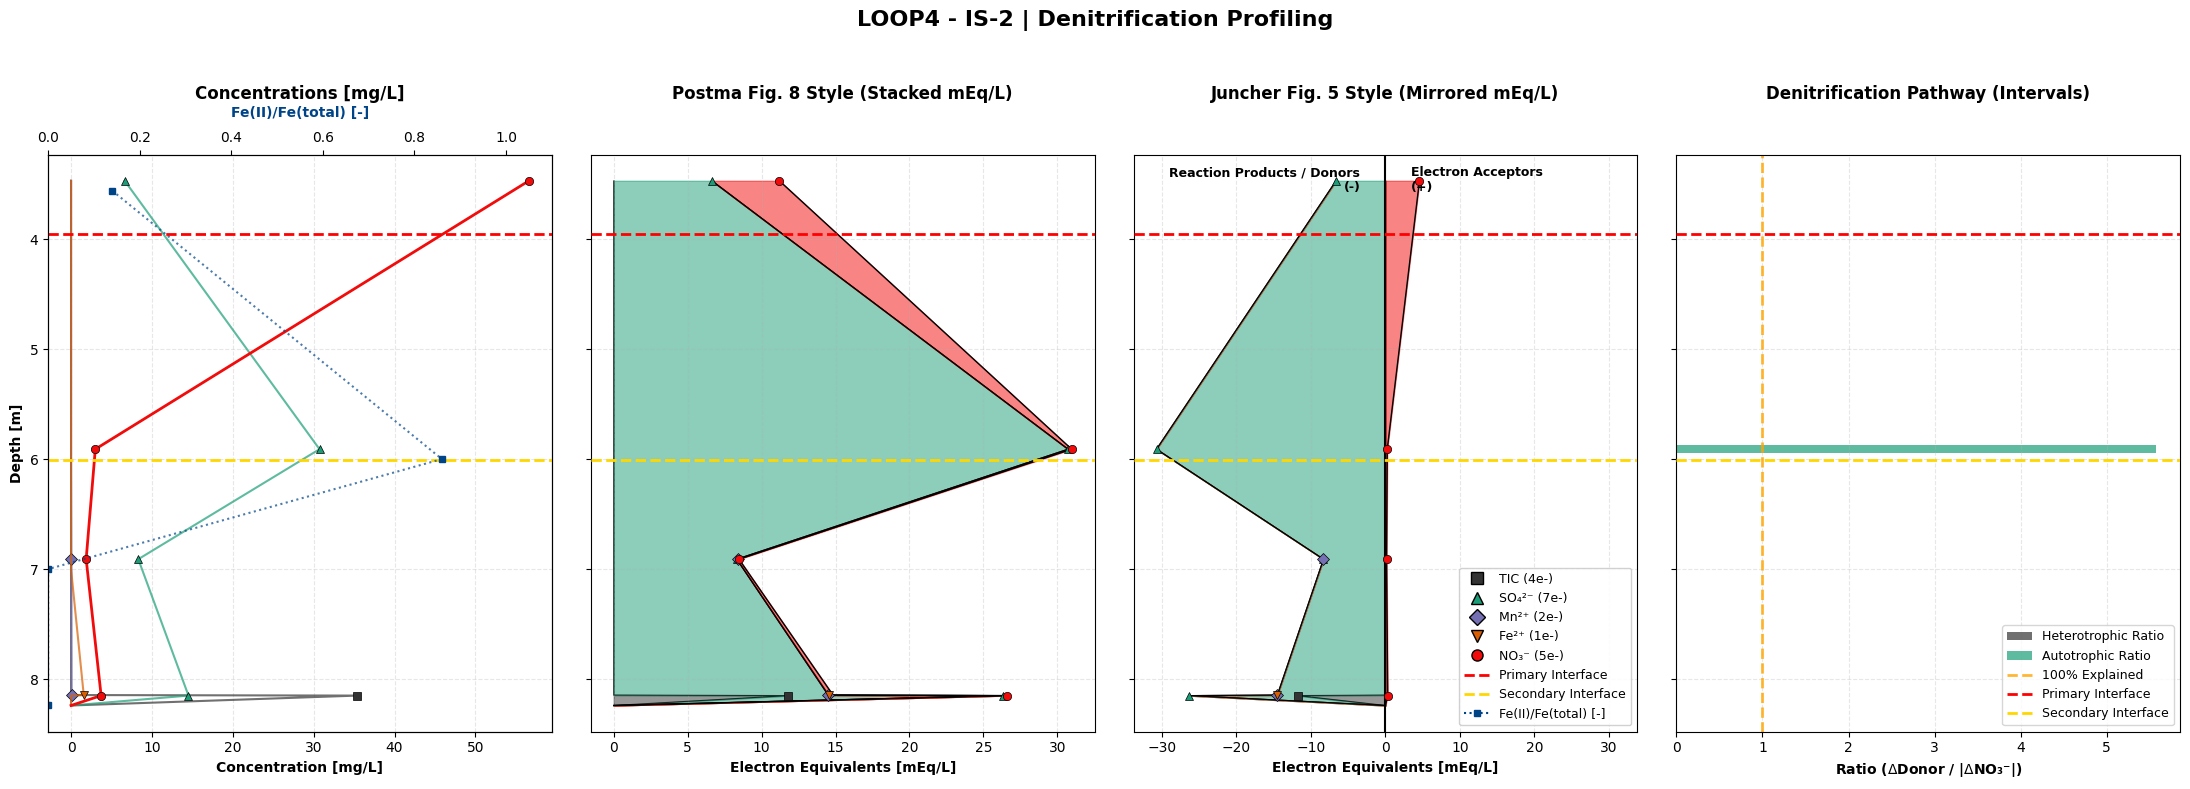

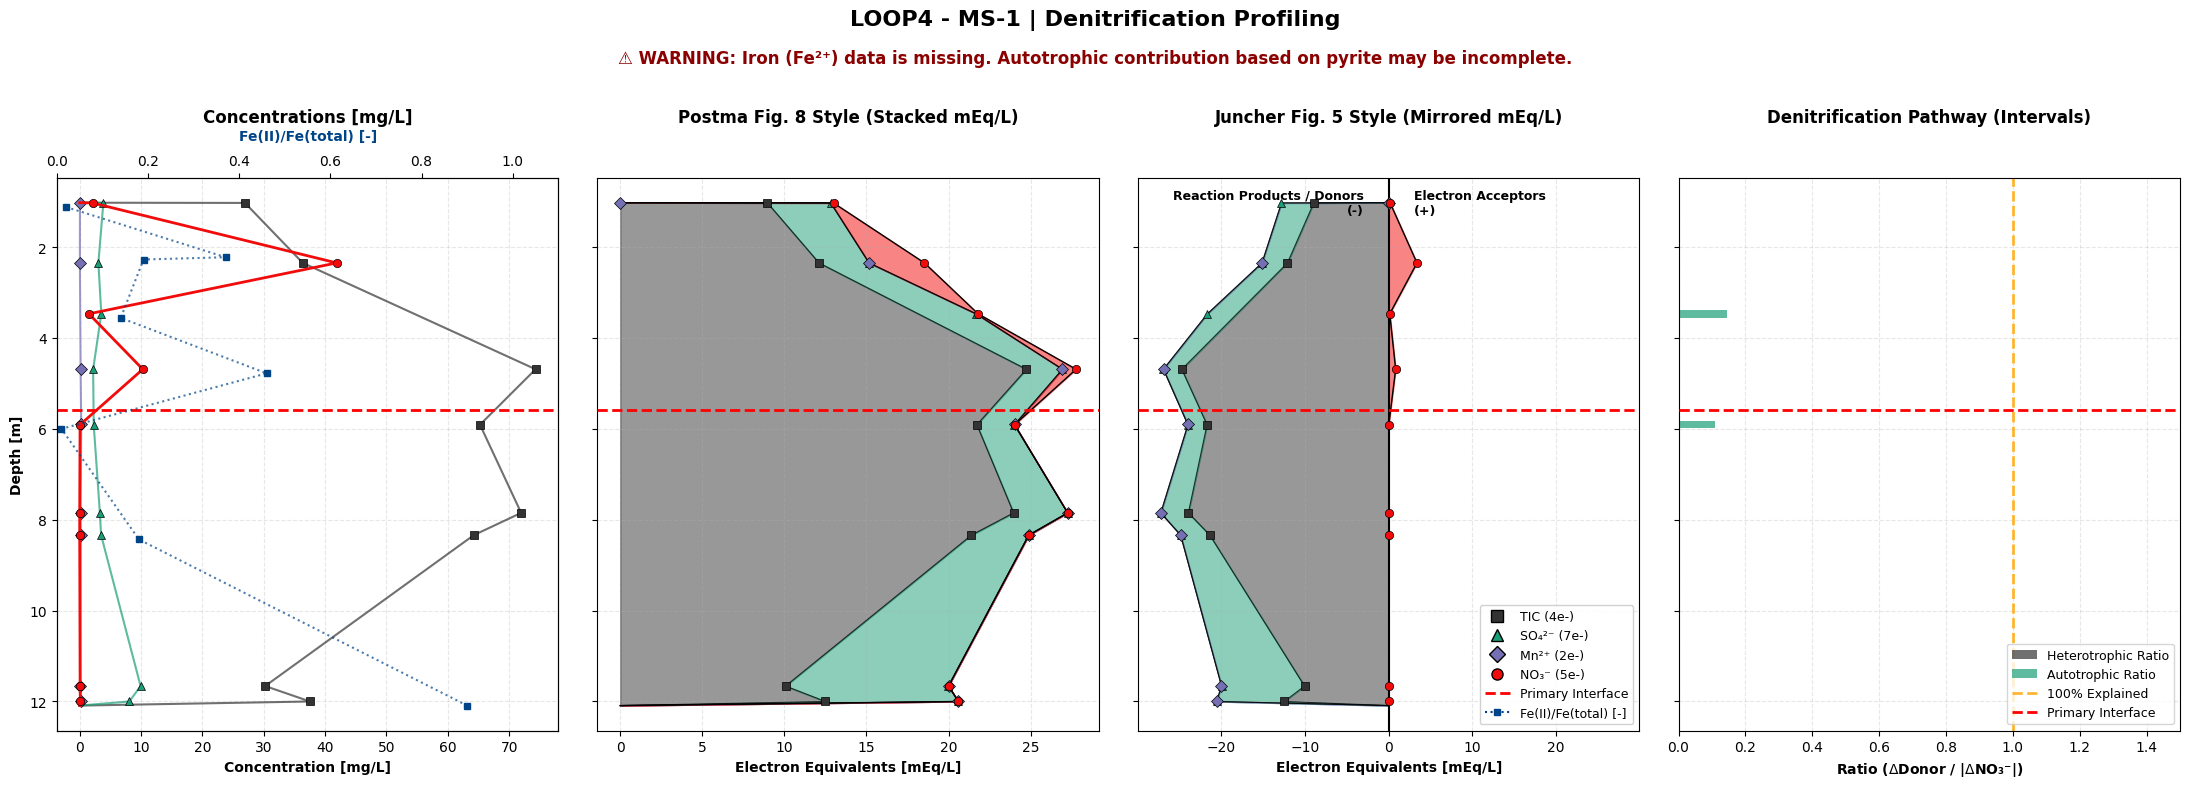

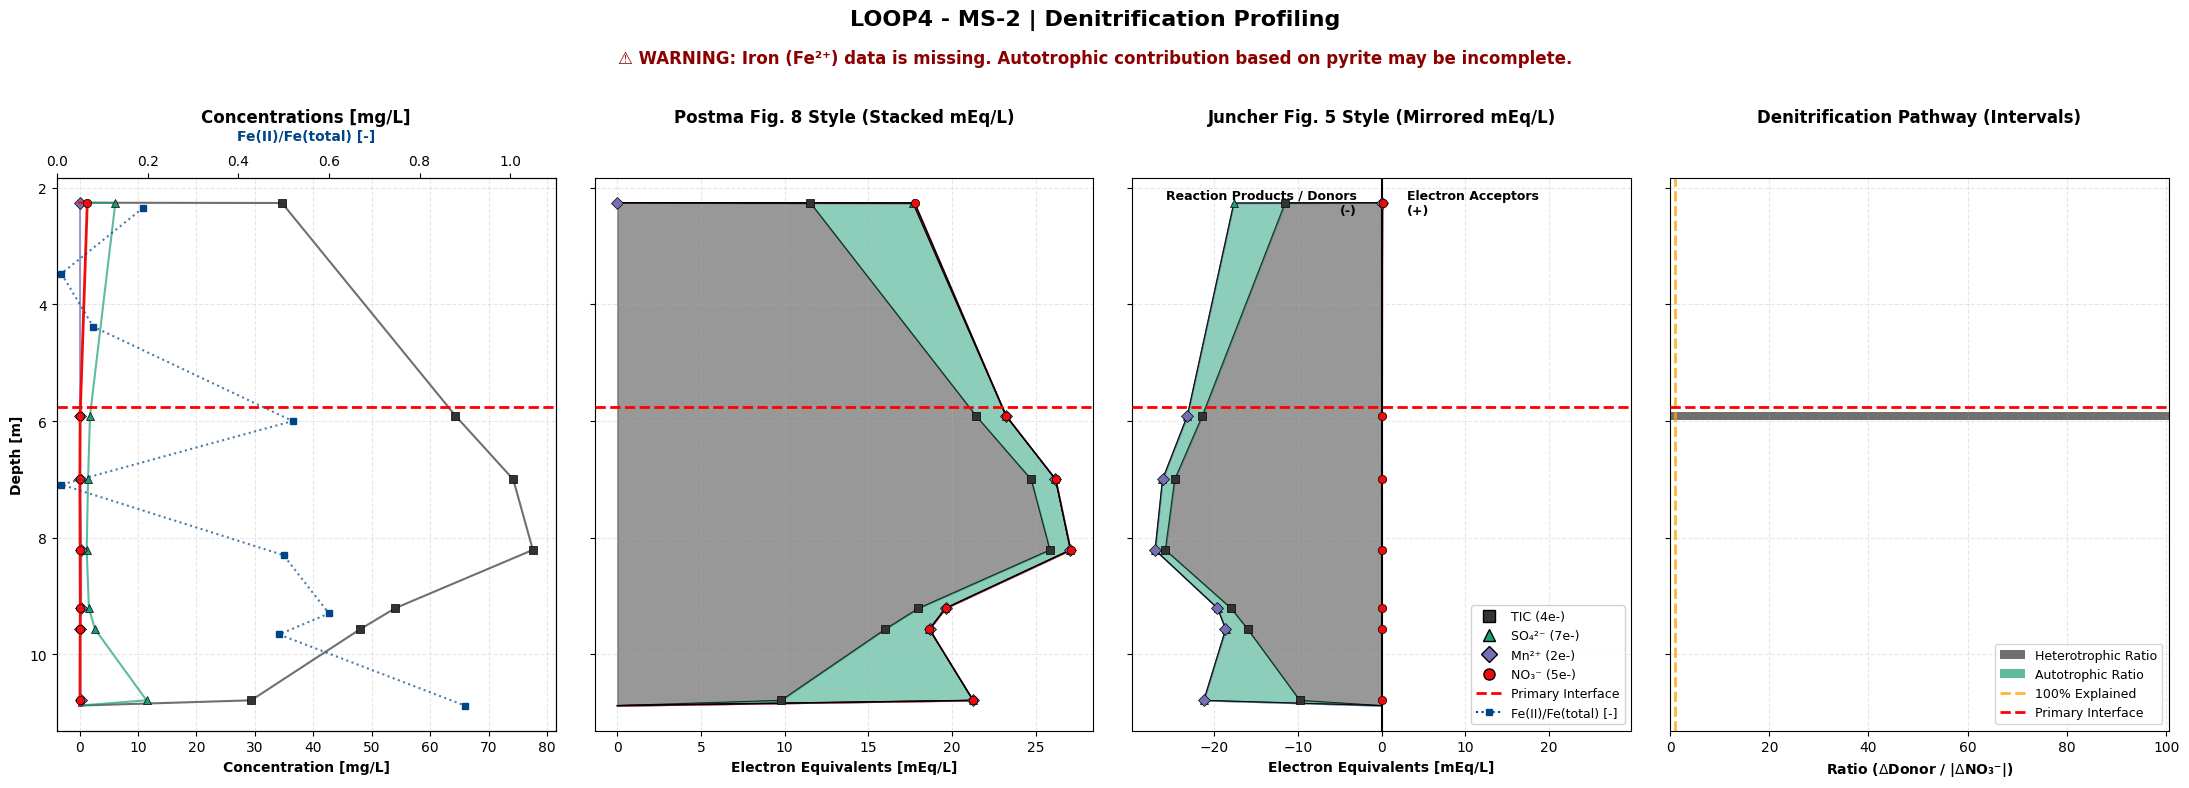

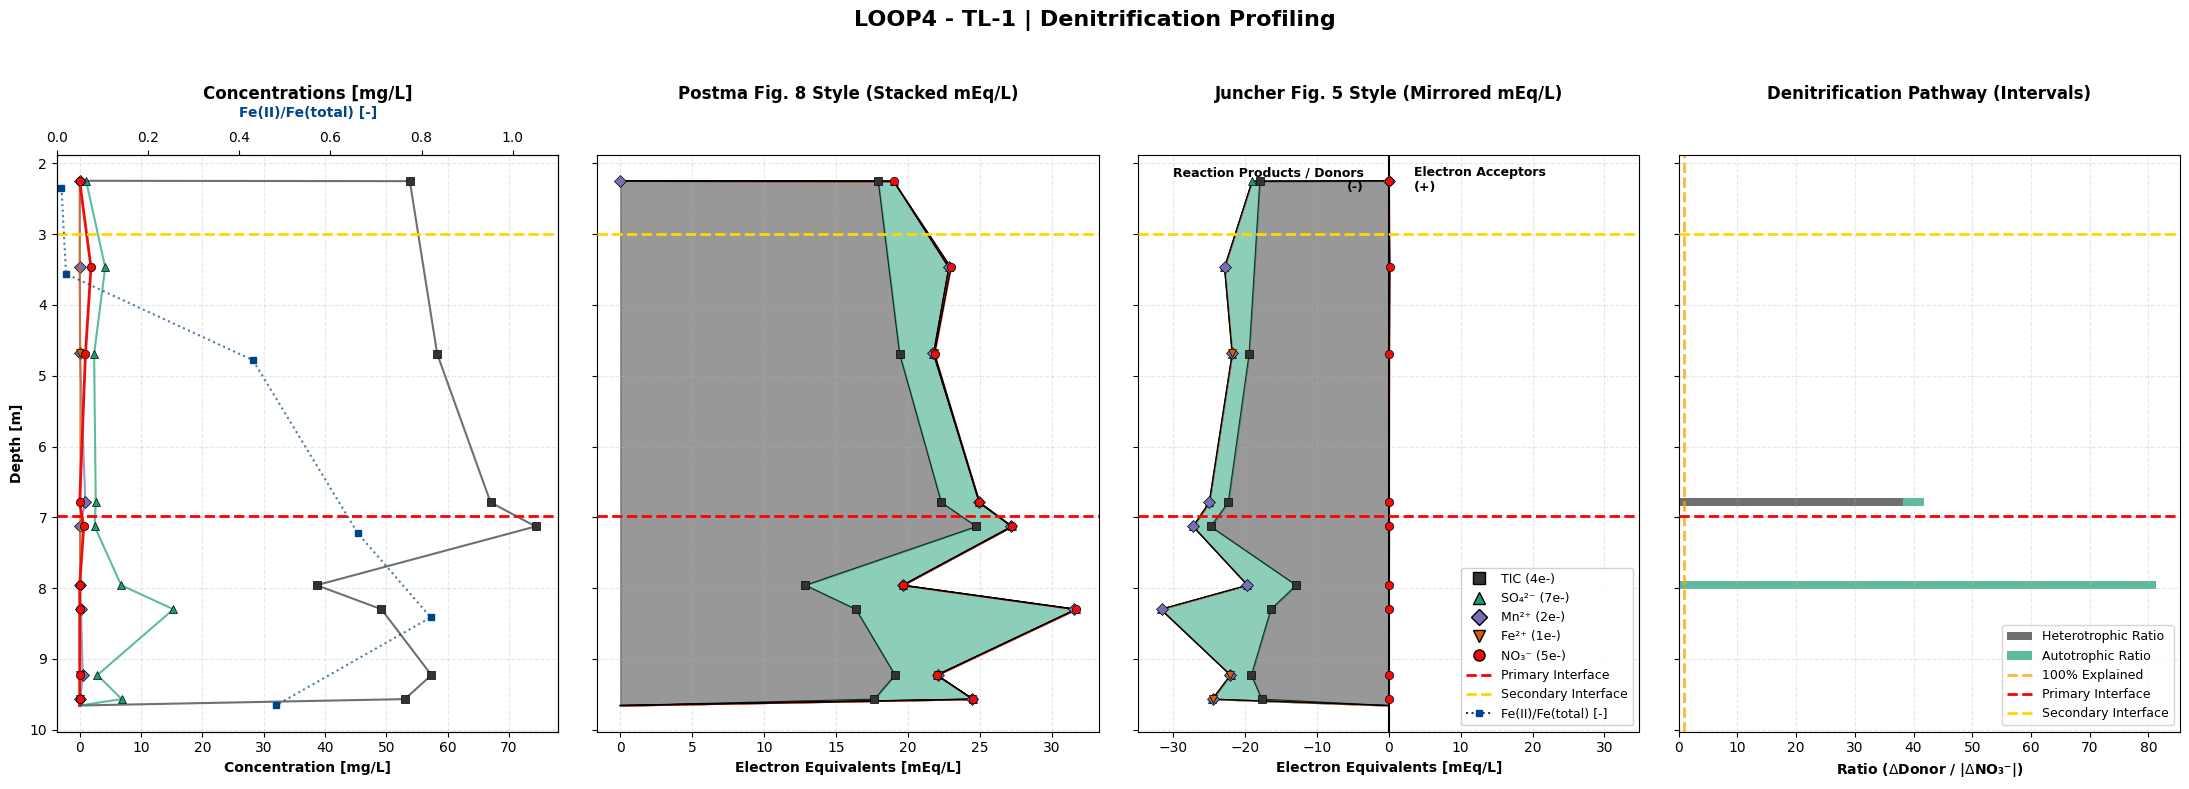

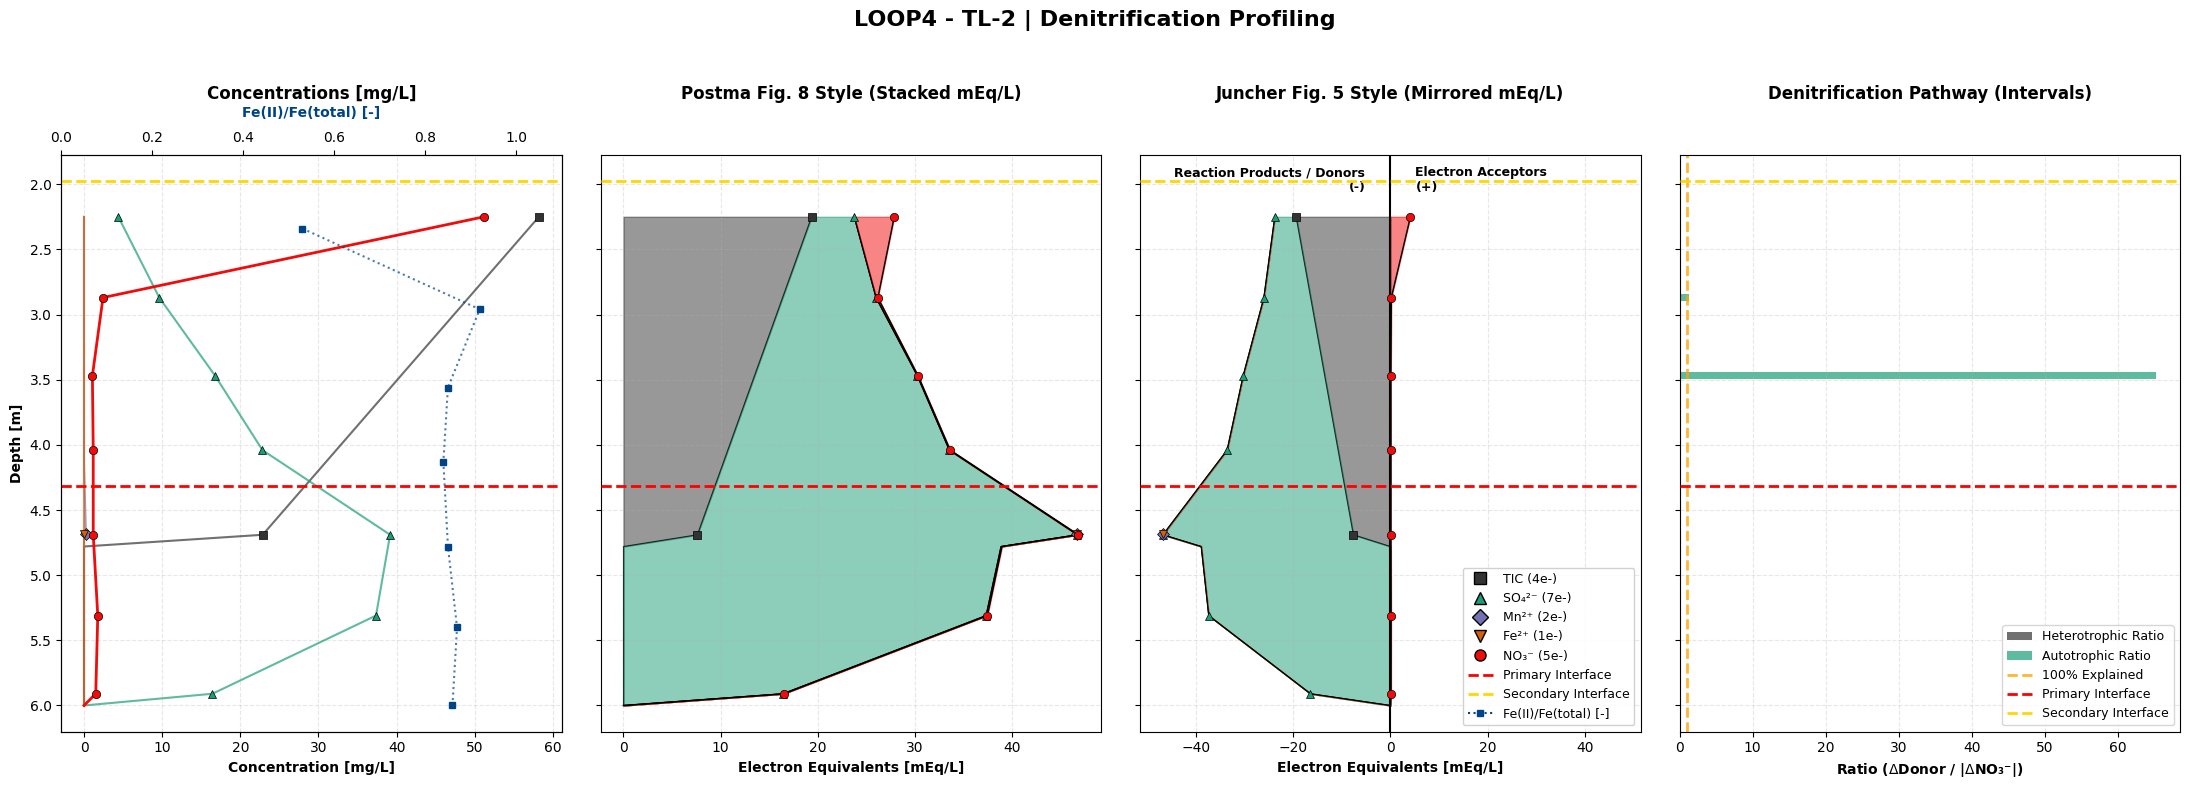

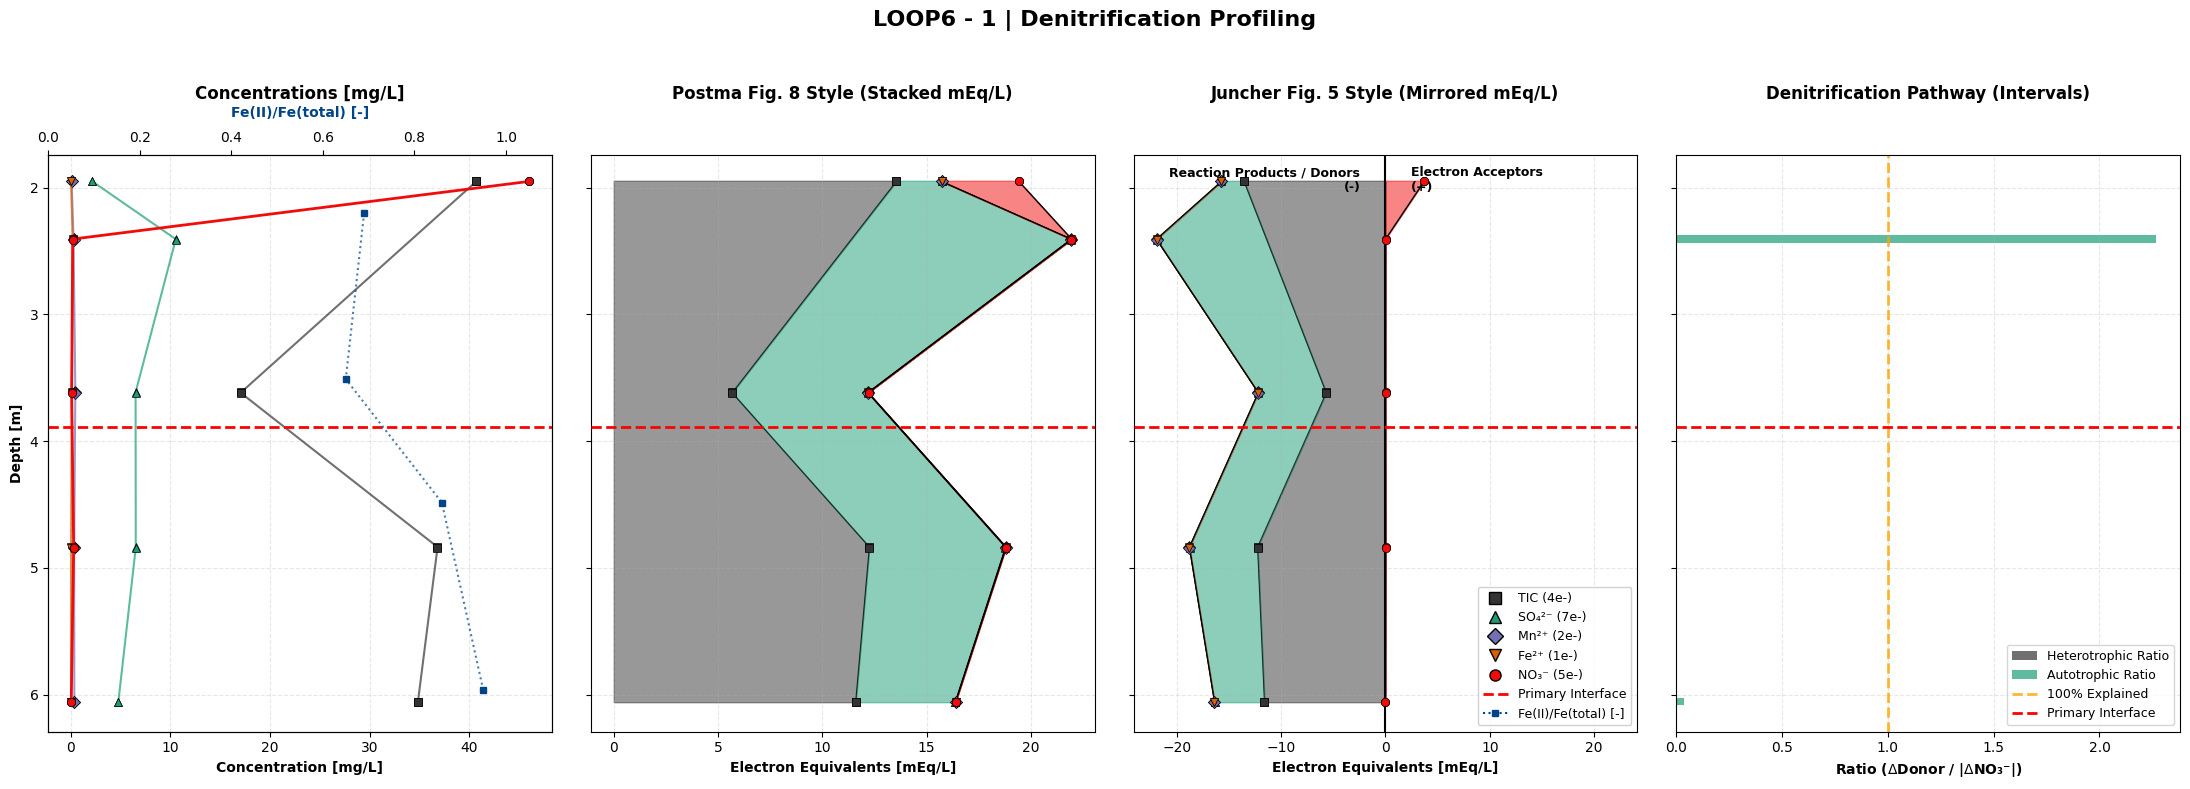

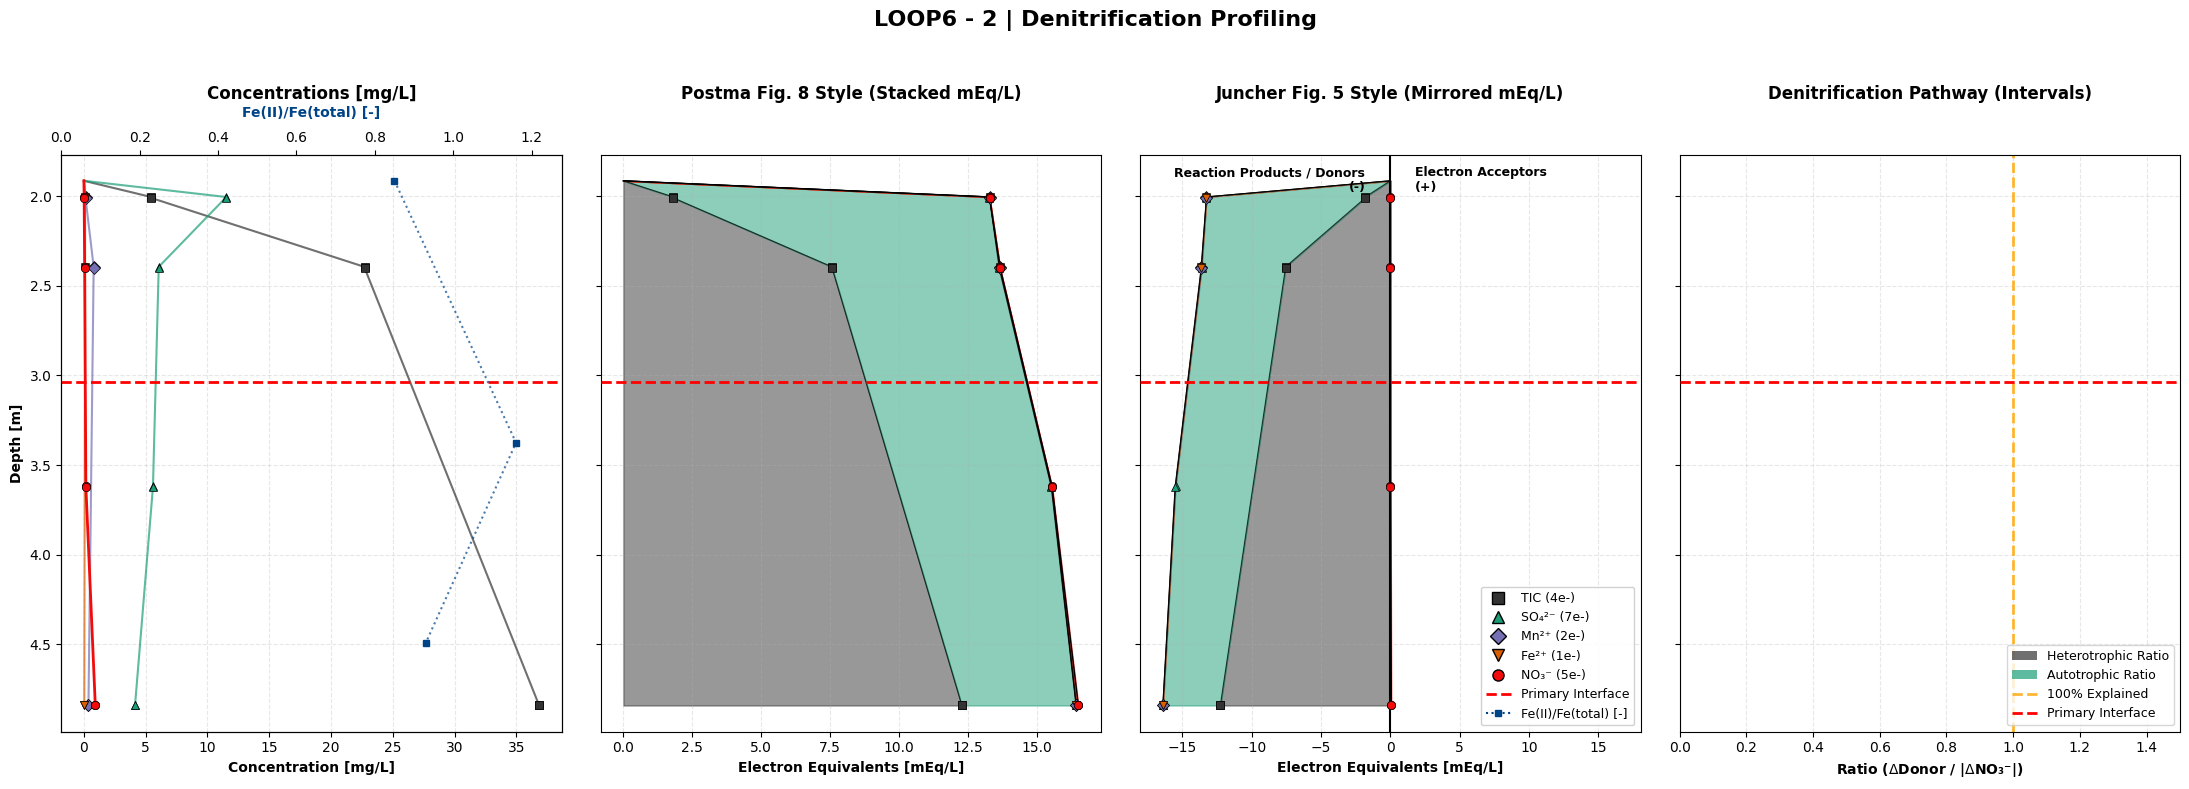

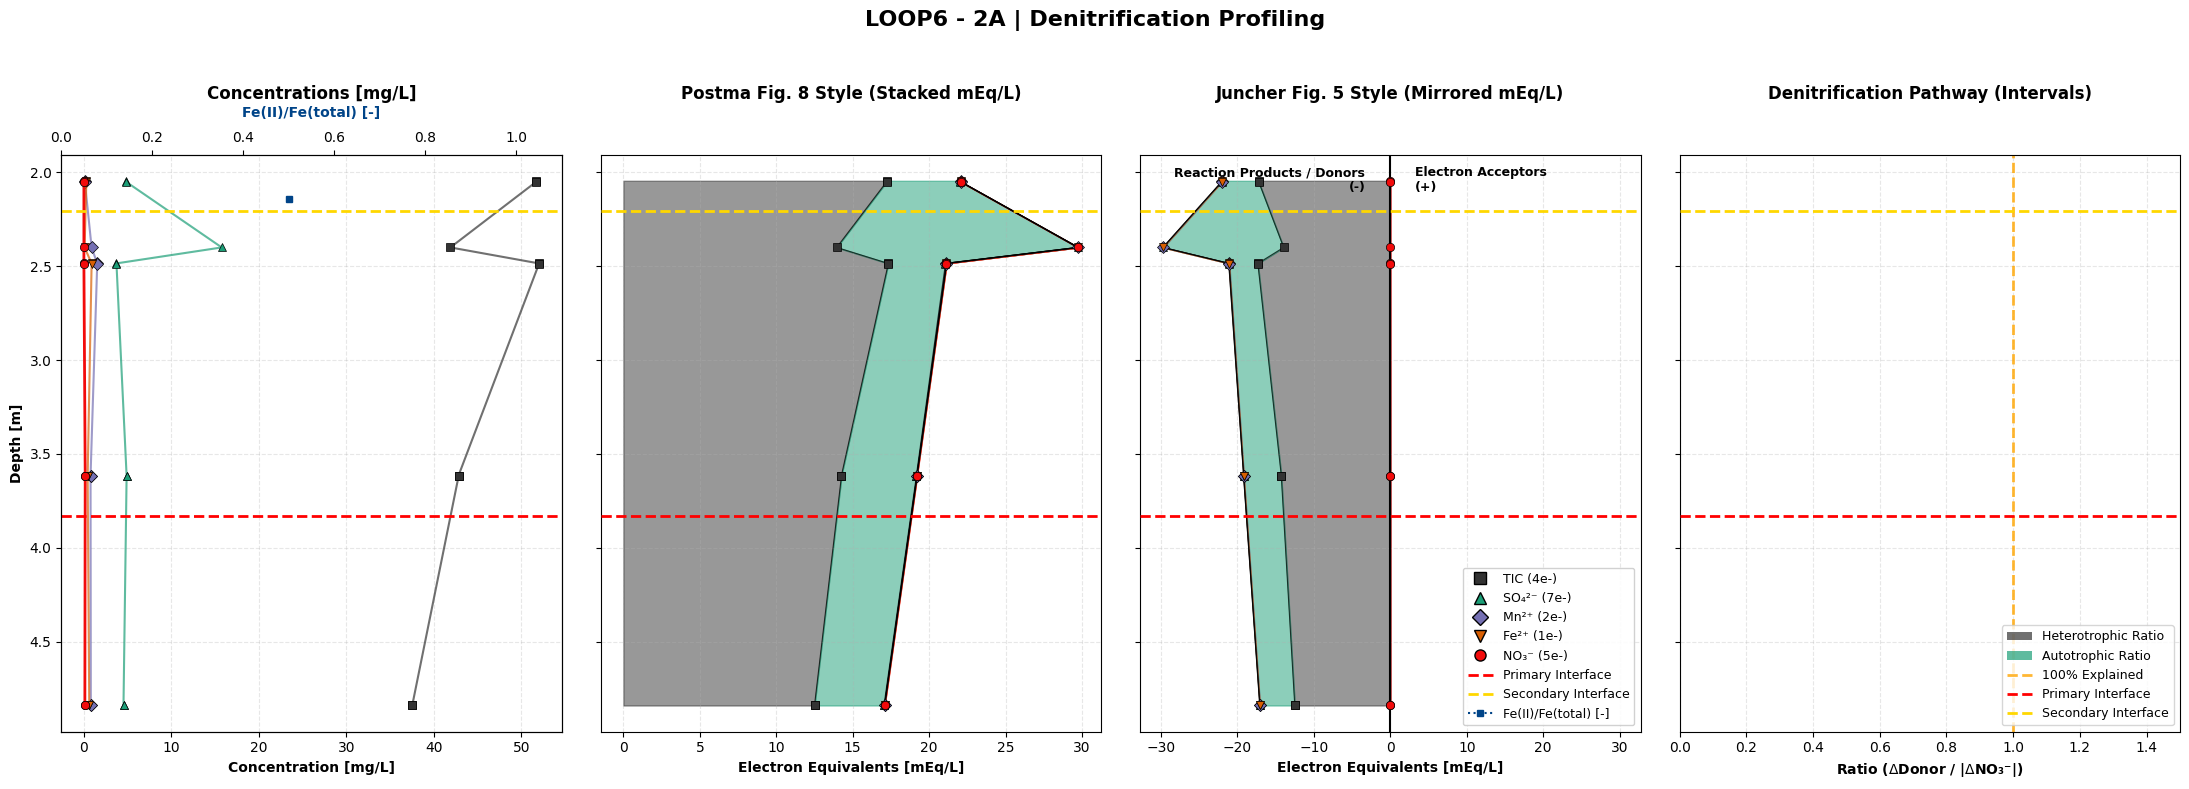

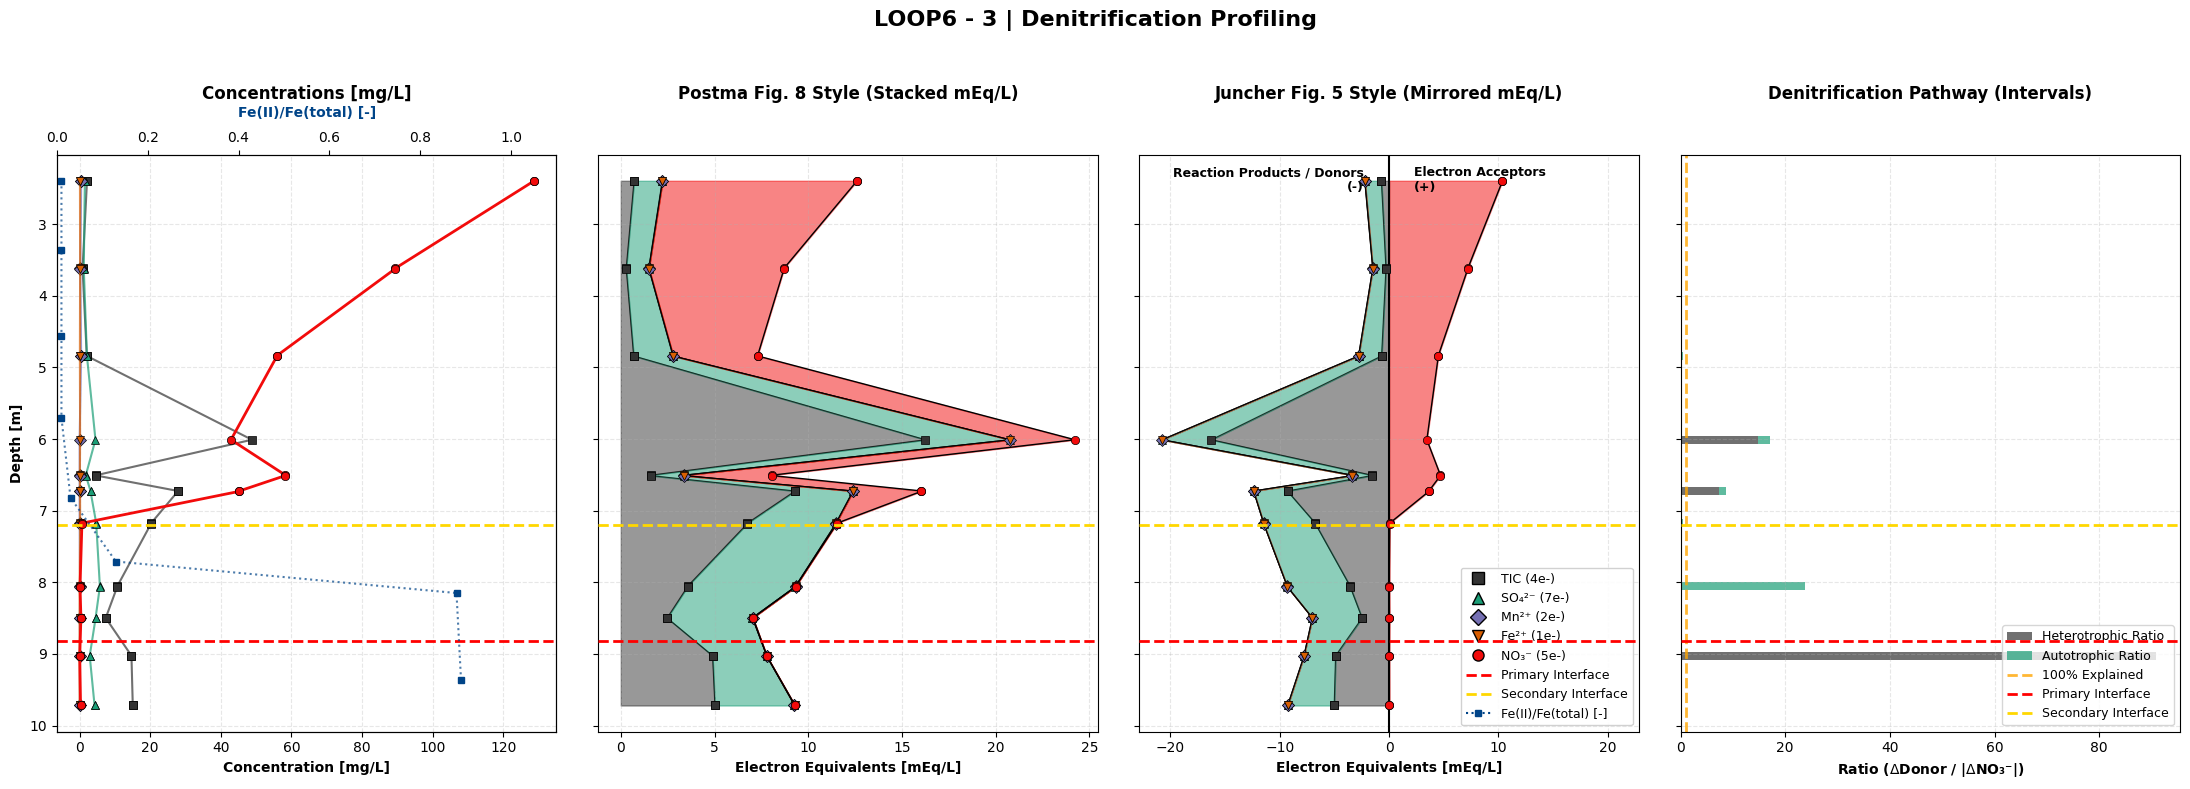

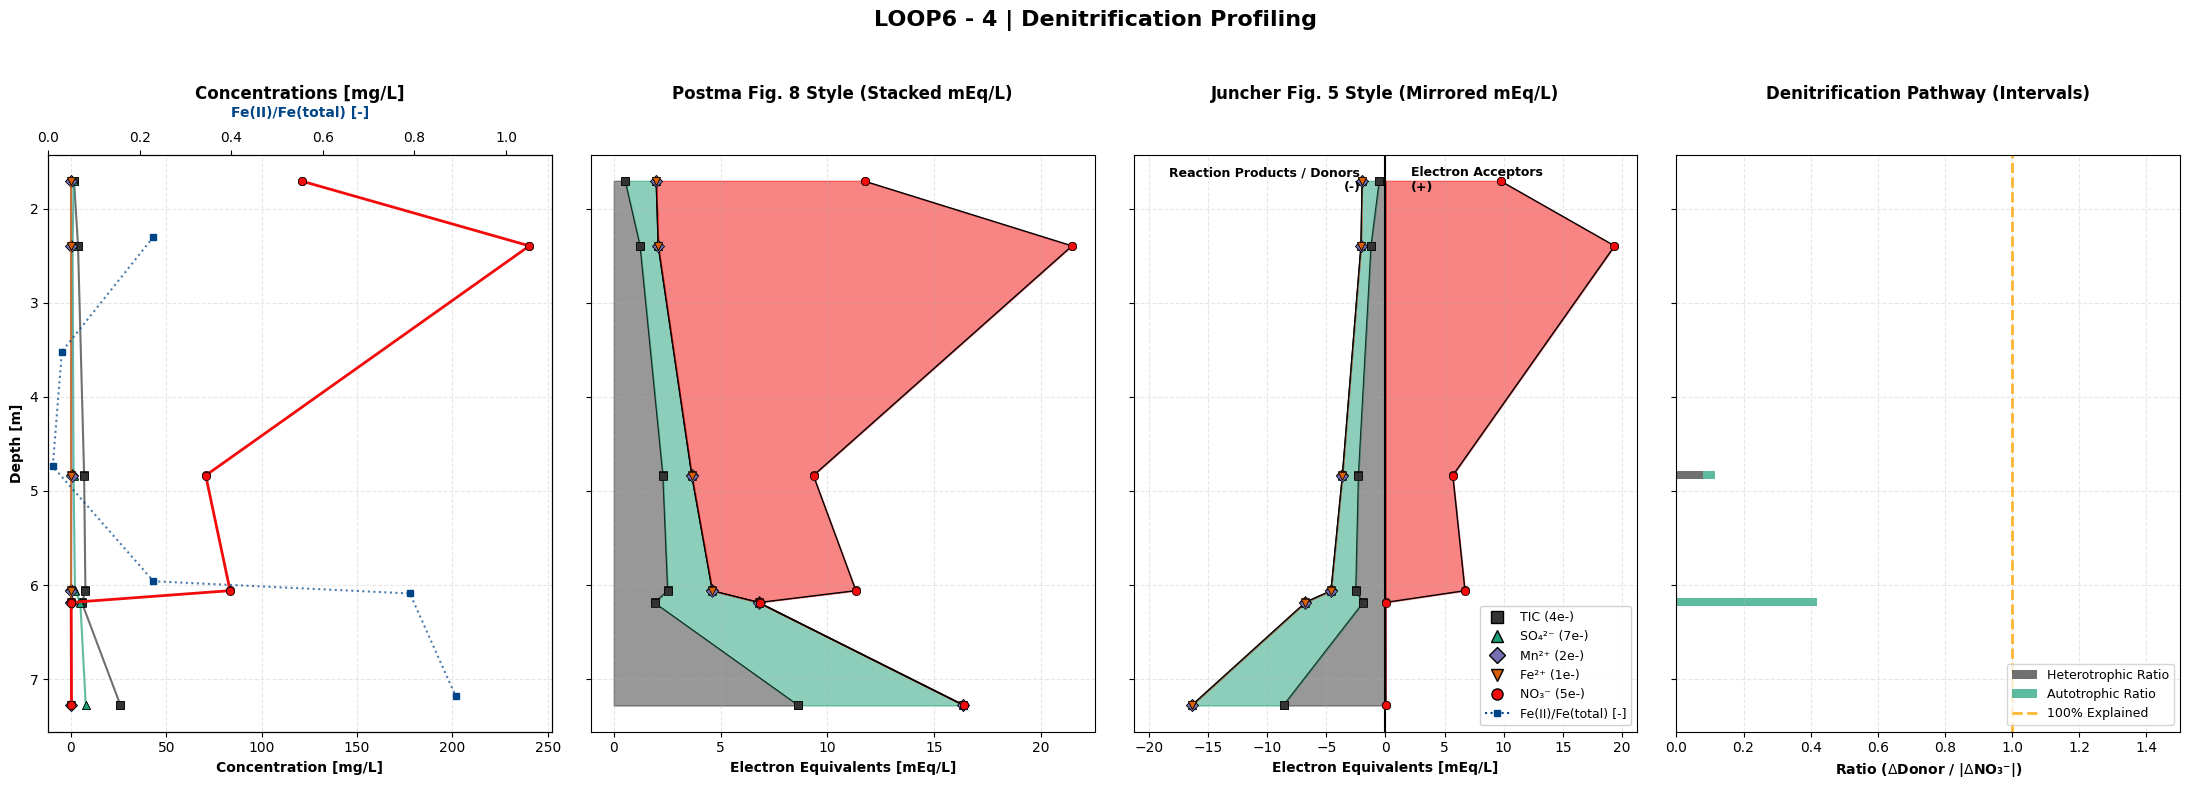

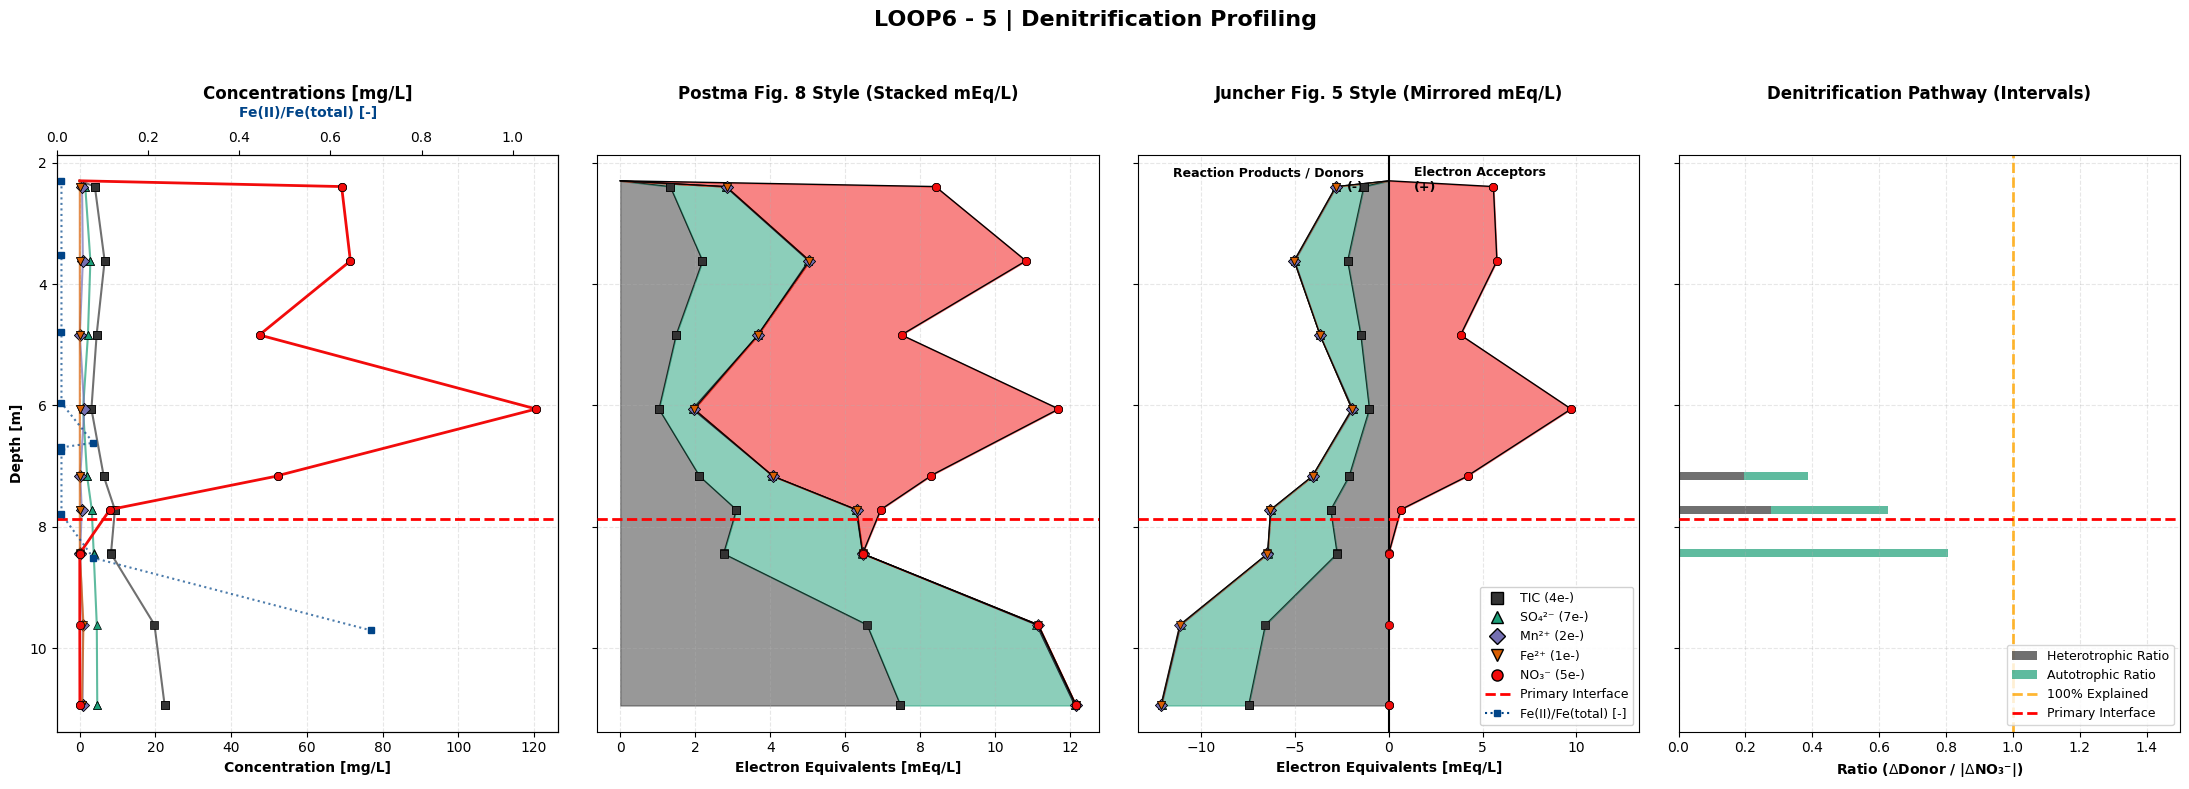

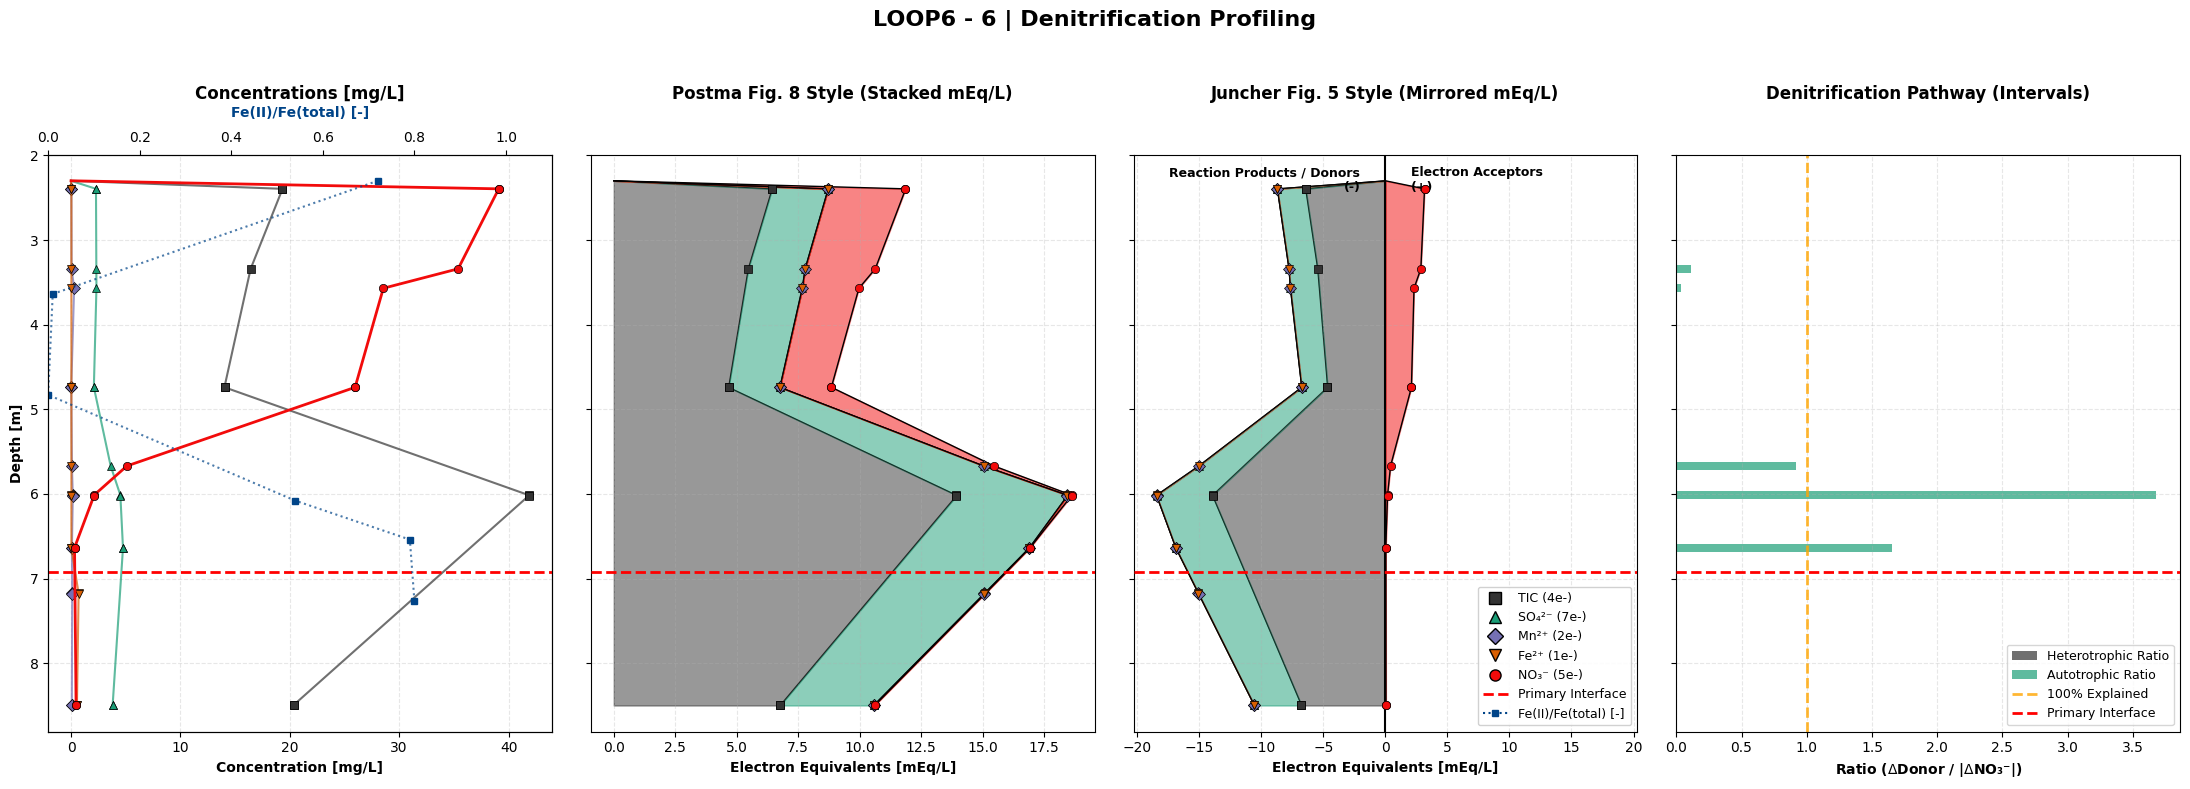

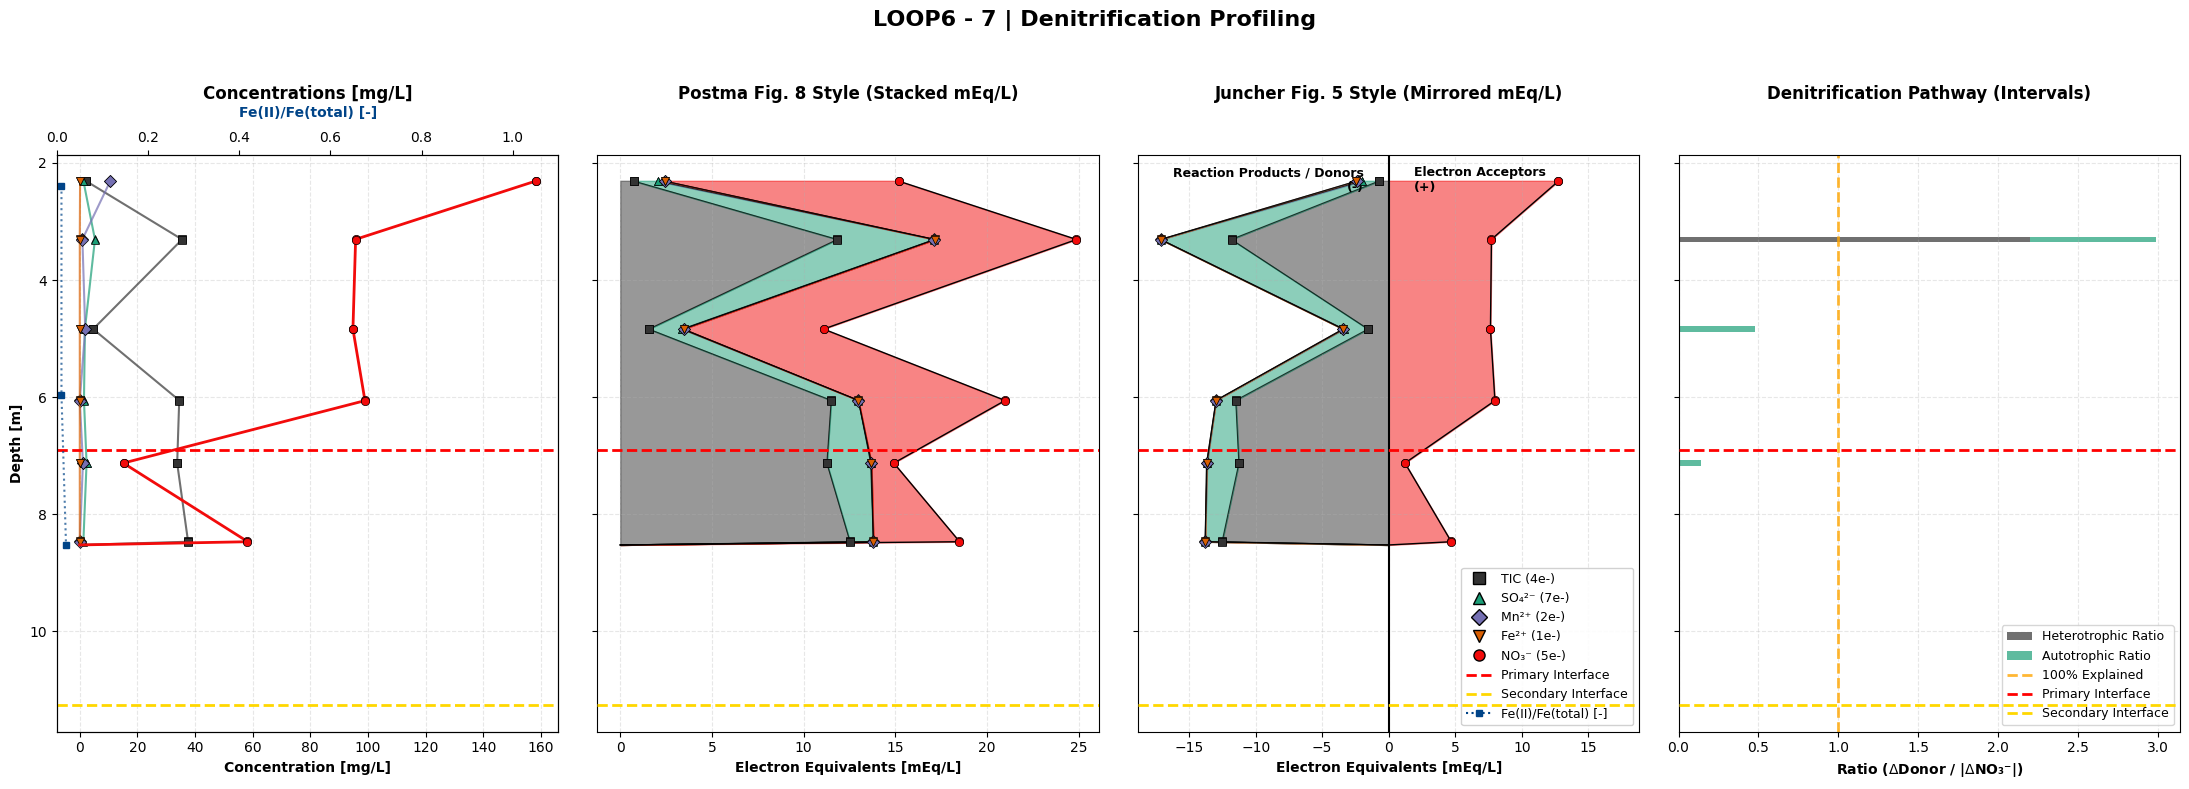

In [5]:
# --- PLOTTING FUNCTIONS ---
def plot_borehole(loop, norm_id, group):
    # Sort by depth
    group = group.sort_values('Depth (m)')
    
    available_meq_cols = [c for c in meq_cols if c in group.columns]
    available_mg_cols = [c.replace(' [mEq/L]', ' [mg/L]') for c in available_meq_cols]
    
    cols_to_interp = available_meq_cols + available_mg_cols
    if 'Fe(II)/Fe(total) [-]' in group.columns:
        cols_to_interp.append('Fe(II)/Fe(total) [-]')
        
    cols_to_interp = list(set(cols_to_interp).intersection(group.columns))
    group = group.dropna(subset=cols_to_interp, how='all')
    
    min_depth = group['Depth (m)'].min()
    max_depth = group['Depth (m)'].max()
    if pd.isna(min_depth) or pd.isna(max_depth): return
        
    group = group.groupby('Depth (m)', as_index=False).mean(numeric_only=True)
    # Store where the RAW non-interpolated data was present
    group_notna = group.set_index('Depth (m)')[cols_to_interp].notna()
    
    group = group.set_index('Depth (m)')
    all_depths = group.index.unique()
    group = group.reindex(all_depths)
    group[cols_to_interp] = group[cols_to_interp].interpolate(method='index', limit_area='inside')
    group = group.reset_index()
    
    if group[available_meq_cols].dropna(how='all').empty: return
        
    depths = group['Depth (m)'].values
    
    valid_indices = {}
    for col in available_meq_cols:
        species_key = col.split(' [')[0]
        if col in group_notna.columns:
            valid_depths = group_notna[group_notna[col]].index.tolist()
            valid_indices[species_key] = [np.where(depths == d)[0][0] for d in valid_depths]
        else:
            valid_indices[species_key] = []

    tic = group['TIC [mEq/L]'].fillna(0).values if 'TIC [mEq/L]' in group.columns else np.zeros(len(depths))
    no3 = group['NO₃⁻ [mEq/L]'].fillna(0).values if 'NO₃⁻ [mEq/L]' in group.columns else np.zeros(len(depths))
    so4 = group['SO₄²⁻ [mEq/L]'].fillna(0).values if 'SO₄²⁻ [mEq/L]' in group.columns else np.zeros(len(depths))
    fe = group['Fe²⁺ [mEq/L]'].fillna(0).values if 'Fe²⁺ [mEq/L]' in group.columns else np.zeros(len(depths))
    mn = group['Mn²⁺ [mEq/L]'].fillna(0).values if 'Mn²⁺ [mEq/L]' in group.columns else np.zeros(len(depths))
    
    tic_mg = group['TIC [mg/L]'].fillna(0).values if 'TIC [mg/L]' in group.columns else np.zeros(len(depths))
    no3_mg = group['NO₃⁻ [mg/L]'].fillna(0).values if 'NO₃⁻ [mg/L]' in group.columns else np.zeros(len(depths))
    so4_mg = group['SO₄²⁻ [mEq/L]'].fillna(0).values if 'SO₄²⁻ [mg/L]' in group.columns else np.zeros(len(depths))
    fe_mg = group['Fe²⁺ [mg/L]'].fillna(0).values if 'Fe²⁺ [mg/L]' in group.columns else np.zeros(len(depths))
    mn_mg = group['Mn²⁺ [mg/L]'].fillna(0).values if 'Mn²⁺ [mg/L]' in group.columns else np.zeros(len(depths))
    
    fe_ratio = group['Fe(II)/Fe(total) [-]'].values if 'Fe(II)/Fe(total) [-]' in group.columns else np.full(len(depths), np.nan)
    fe_ratio_valid = []
    if 'Fe(II)/Fe(total) [-]' in group_notna.columns:
        valid_depths = group_notna[group_notna['Fe(II)/Fe(total) [-]']].index.tolist()
        fe_ratio_valid = [np.where(depths == d)[0][0] for d in valid_depths]
    
    has_tic = tic.max() > 0 or len(valid_indices.get('TIC', [])) > 0
    has_no3 = no3.max() > 0 or len(valid_indices.get('NO₃⁻', [])) > 0
    has_so4 = so4.max() > 0 or len(valid_indices.get('SO₄²⁻', [])) > 0
    has_fe = fe.max() > 0 or len(valid_indices.get('Fe²⁺', [])) > 0
    has_mn = mn.max() > 0 or len(valid_indices.get('Mn²⁺', [])) > 0
    has_fe_ratio = PLOT_FE_RATIO and len(fe_ratio_valid) > 0
    
    primary_interface_depth = np.nan
    secondary_interface_depth = np.nan
    interface_row = df_interfaces[(df_interfaces['LOOPNr'] == loop) & (df_interfaces['Norm_ID'] == norm_id)]
    if not interface_row.empty:
        if PLOT_PRIMARY_INTERFACE:
            primary_interface_depth = interface_row['Main_Drop_Z'].iloc[0]
        if PLOT_SECONDARY_INTERFACE:
            secondary_interface_depth = interface_row['Sec_Drop_Z'].iloc[0]
    
    if not (has_tic or has_no3 or has_so4 or has_fe or has_mn): return

    fig, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, figsize=(22, 8), sharey=True)
    
    # Title and Warning logic
    title_str = f"{loop} - {norm_id} | Denitrification Profiling"
    fig.suptitle(title_str, fontsize=16, fontweight='bold', color='black', y=0.98)
    
    if not has_fe:
        fig.text(0.5, 0.93, "⚠ WARNING: Iron (Fe²⁺) data is missing. Autotrophic contribution based on pyrite may be incomplete.", 
                 ha='center', va='top', fontsize=12, color='darkred', fontweight='bold')
    
    DOT_SIZE = 6          
    DOT_ALPHA = 0.5       
    
    MARKERS = {
        'TIC': 's',     # square
        'SO₄²⁻': '^',   # triangle up
        'Mn²⁺': 'D',    # diamond
        'Fe²⁺': 'v',    # triangle down
        'NO₃⁻': 'o'     # circle
    }
    
    handles = []

    # === AX0: CONCENTRATIONS [mg/L] ===
    ax0.set_title("Concentrations [mg/L]", fontweight='bold', pad=40)
    if has_tic:
        ax0.plot(tic_mg, depths, color=COLOR_MAP['TIC [mEq/L]'], linewidth=1.5, alpha=0.7)
        ax0.plot(tic_mg[valid_indices.get('TIC', [])], depths[valid_indices.get('TIC', [])], MARKERS['TIC'], color=COLOR_MAP['TIC [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5)
    if has_so4:
        ax0.plot(so4_mg, depths, color=COLOR_MAP['SO₄²⁻ [mEq/L]'], linewidth=1.5, alpha=0.7)
        ax0.plot(so4_mg[valid_indices.get('SO₄²⁻', [])], depths[valid_indices.get('SO₄²⁻', [])], MARKERS['SO₄²⁻'], color=COLOR_MAP['SO₄²⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5)
    if has_mn:
        ax0.plot(mn_mg, depths, color=COLOR_MAP['Mn²⁺ [mEq/L]'], linewidth=1.5, alpha=0.7)
        ax0.plot(mn_mg[valid_indices.get('Mn²⁺', [])], depths[valid_indices.get('Mn²⁺', [])], MARKERS['Mn²⁺'], color=COLOR_MAP['Mn²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5)
    if has_fe:
        ax0.plot(fe_mg, depths, color=COLOR_MAP['Fe²⁺ [mEq/L]'], linewidth=1.5, alpha=0.7)
        ax0.plot(fe_mg[valid_indices.get('Fe²⁺', [])], depths[valid_indices.get('Fe²⁺', [])], MARKERS['Fe²⁺'], color=COLOR_MAP['Fe²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5)
    if has_no3:
        ax0.plot(no3_mg, depths, color=COLOR_MAP['NO₃⁻ [mEq/L]'], linewidth=2.0)
        ax0.plot(no3_mg[valid_indices.get('NO₃⁻', [])], depths[valid_indices.get('NO₃⁻', [])], MARKERS['NO₃⁻'], color=COLOR_MAP['NO₃⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5)

    ax0.set_xlabel("Concentration [mg/L]", fontweight='bold')
    ax0.set_ylabel("Depth [m]", fontweight='bold')
    ax0.invert_yaxis()
    ax0.grid(True, linestyle='--', alpha=0.3)
    
    if has_fe_ratio:
        ax0_top = ax0.twiny()
        ax0_top.plot(fe_ratio, depths, color='#004488', linestyle=':', linewidth=1.5, alpha=0.7)
        ax0_top.plot(fe_ratio[fe_ratio_valid], depths[fe_ratio_valid], 's', color='#004488', markersize=4)
        ax0_top.set_xlabel('Fe(II)/Fe(total) [-]', color='#004488', fontweight='bold', labelpad=10)
        ax0_top.set_xlim(0, max(1.1, np.nanmax(fe_ratio)*1.1))

    # === AX1: POSTMA FIG 8 (Stacked) ===
    ax1.set_title("Postma Fig. 8 Style (Stacked mEq/L)", fontweight='bold', pad=40)
    c_tic = tic
    c_so4 = c_tic + so4
    c_mn = c_so4 + mn
    c_fe = c_mn + fe
    c_no3 = c_fe + no3
    
    from matplotlib.lines import Line2D
    
    if has_tic:
        ax1.fill_betweenx(depths, 0, c_tic, color=COLOR_MAP['TIC [mEq/L]'], alpha=DOT_ALPHA)
        ax1.plot(c_tic[valid_indices.get('TIC', [])], depths[valid_indices.get('TIC', [])], MARKERS['TIC'], color=COLOR_MAP['TIC [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
        handles.append(Line2D([0], [0], marker=MARKERS['TIC'], color='w', markerfacecolor=COLOR_MAP['TIC [mEq/L]'], markeredgecolor='black', markersize=DOT_SIZE+2, label='TIC (4e-)'))
    if has_so4:
        ax1.fill_betweenx(depths, c_tic, c_so4, color=COLOR_MAP['SO₄²⁻ [mEq/L]'], alpha=DOT_ALPHA)
        ax1.plot(c_so4[valid_indices.get('SO₄²⁻', [])], depths[valid_indices.get('SO₄²⁻', [])], MARKERS['SO₄²⁻'], color=COLOR_MAP['SO₄²⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
        handles.append(Line2D([0], [0], marker=MARKERS['SO₄²⁻'], color='w', markerfacecolor=COLOR_MAP['SO₄²⁻ [mEq/L]'], markeredgecolor='black', markersize=DOT_SIZE+2, label='SO₄²⁻ (7e-)'))
    if has_mn:
        ax1.fill_betweenx(depths, c_so4, c_mn, color=COLOR_MAP['Mn²⁺ [mEq/L]'], alpha=DOT_ALPHA)
        ax1.plot(c_mn[valid_indices.get('Mn²⁺', [])], depths[valid_indices.get('Mn²⁺', [])], MARKERS['Mn²⁺'], color=COLOR_MAP['Mn²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
        handles.append(Line2D([0], [0], marker=MARKERS['Mn²⁺'], color='w', markerfacecolor=COLOR_MAP['Mn²⁺ [mEq/L]'], markeredgecolor='black', markersize=DOT_SIZE+2, label='Mn²⁺ (2e-)'))
    if has_fe:
        ax1.fill_betweenx(depths, c_mn, c_fe, color=COLOR_MAP['Fe²⁺ [mEq/L]'], alpha=DOT_ALPHA)
        ax1.plot(c_fe[valid_indices.get('Fe²⁺', [])], depths[valid_indices.get('Fe²⁺', [])], MARKERS['Fe²⁺'], color=COLOR_MAP['Fe²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
        handles.append(Line2D([0], [0], marker=MARKERS['Fe²⁺'], color='w', markerfacecolor=COLOR_MAP['Fe²⁺ [mEq/L]'], markeredgecolor='black', markersize=DOT_SIZE+2, label='Fe²⁺ (1e-)'))
    if has_no3:
        ax1.fill_betweenx(depths, c_fe, c_no3, color=COLOR_MAP['NO₃⁻ [mEq/L]'], alpha=DOT_ALPHA)
        ax1.plot(c_no3[valid_indices.get('NO₃⁻', [])], depths[valid_indices.get('NO₃⁻', [])], MARKERS['NO₃⁻'], color=COLOR_MAP['NO₃⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
        handles.append(Line2D([0], [0], marker=MARKERS['NO₃⁻'], color='w', markerfacecolor=COLOR_MAP['NO₃⁻ [mEq/L]'], markeredgecolor='black', markersize=DOT_SIZE+2, label='NO₃⁻ (5e-)'))

    if has_tic: ax1.plot(c_tic, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_so4: ax1.plot(c_so4, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_mn: ax1.plot(c_mn, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_fe: ax1.plot(c_fe, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_no3: ax1.plot(c_no3, depths, color='black', linewidth=1.0)
    
    if pd.notna(primary_interface_depth) and PLOT_PRIMARY_INTERFACE:
        handles.append(plt.Line2D([0],[0], color='red', linestyle='--', linewidth=2.0, label='Primary Interface'))
    if pd.notna(secondary_interface_depth) and PLOT_SECONDARY_INTERFACE:
        handles.append(plt.Line2D([0],[0], color='gold', linestyle='--', linewidth=2.0, label='Secondary Interface'))
        
    if has_fe_ratio:
        handles.append(Line2D([0],[0], color='#004488', linestyle=':', marker='s', markersize=4, label='Fe(II)/Fe(total) [-]'))

    ax1.set_xlabel("Electron Equivalents [mEq/L]", fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # === AX2: JUNCHER FIG 5 (Mirrored) ===
    ax2.set_title("Juncher Fig. 5 Style (Mirrored mEq/L)", fontweight='bold', pad=40)
    n_tic = -tic
    n_so4 = n_tic - so4
    n_mn = n_so4 - mn
    n_fe = n_mn - fe
    p_no3 = no3
    
    ax2.axvline(0, color='black', linewidth=1.5)
    if has_tic:
        ax2.fill_betweenx(depths, 0, n_tic, color=COLOR_MAP['TIC [mEq/L]'], alpha=DOT_ALPHA)
        ax2.plot(n_tic[valid_indices.get('TIC', [])], depths[valid_indices.get('TIC', [])], MARKERS['TIC'], color=COLOR_MAP['TIC [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    if has_so4:
        ax2.fill_betweenx(depths, n_tic, n_so4, color=COLOR_MAP['SO₄²⁻ [mEq/L]'], alpha=DOT_ALPHA)
        ax2.plot(n_so4[valid_indices.get('SO₄²⁻', [])], depths[valid_indices.get('SO₄²⁻', [])], MARKERS['SO₄²⁻'], color=COLOR_MAP['SO₄²⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    if has_mn:
        ax2.fill_betweenx(depths, n_so4, n_mn, color=COLOR_MAP['Mn²⁺ [mEq/L]'], alpha=DOT_ALPHA)
        ax2.plot(n_mn[valid_indices.get('Mn²⁺', [])], depths[valid_indices.get('Mn²⁺', [])], MARKERS['Mn²⁺'], color=COLOR_MAP['Mn²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    if has_fe:
        ax2.fill_betweenx(depths, n_mn, n_fe, color=COLOR_MAP['Fe²⁺ [mEq/L]'], alpha=DOT_ALPHA)
        ax2.plot(n_fe[valid_indices.get('Fe²⁺', [])], depths[valid_indices.get('Fe²⁺', [])], MARKERS['Fe²⁺'], color=COLOR_MAP['Fe²⁺ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    if has_no3:
        ax2.fill_betweenx(depths, 0, p_no3, color=COLOR_MAP['NO₃⁻ [mEq/L]'], alpha=DOT_ALPHA)
        ax2.plot(p_no3[valid_indices.get('NO₃⁻', [])], depths[valid_indices.get('NO₃⁻', [])], MARKERS['NO₃⁻'], color=COLOR_MAP['NO₃⁻ [mEq/L]'], markersize=DOT_SIZE, markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    
    if has_tic: ax2.plot(n_tic, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_so4: ax2.plot(n_so4, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_mn: ax2.plot(n_mn, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_fe: ax2.plot(n_fe, depths, color='black', linewidth=0.8, alpha=0.7)
    if has_no3: ax2.plot(p_no3, depths, color='black', linewidth=1.0)

    ax2.text(0.45, 0.98, "Reaction Products / Donors\n(-)", color='black', ha='right', va='top', fontweight='bold', transform=ax2.transAxes, fontsize=9)
    ax2.text(0.55, 0.98, "Electron Acceptors\n(+)", color='black', ha='left', va='top', fontweight='bold', transform=ax2.transAxes, fontsize=9)
    ax2.set_xlabel("Electron Equivalents [mEq/L]", fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.9)
    max_val = max(abs(n_fe.min() if has_fe else (n_mn.min() if has_mn else (n_so4.min() if has_so4 else (n_tic.min() if has_tic else 0)))), p_no3.max() if has_no3 else 0)
    pad = max_val * 0.1 if max_val > 0 else 1
    ax2.set_xlim(-(max_val + pad), max_val + pad)
    
    # === AX3: PATHWAY INTERVALS (Hetero vs Auto) ===
    ax3.set_title("Denitrification Pathway (Intervals)", fontweight='bold', pad=40)
    
    from matplotlib.patches import Patch
    leg3_handles = [
        Patch(facecolor=COLOR_MAP['TIC [mEq/L]'], alpha=0.7, label='Heterotrophic Ratio'),
        Patch(facecolor=COLOR_MAP['SO₄²⁻ [mEq/L]'], alpha=0.7, label='Autotrophic Ratio'),
        plt.Line2D([0],[0], color='orange', linestyle='--', linewidth=2.0, alpha=0.8, label='100% Explained')
    ]
    if pd.notna(primary_interface_depth) and PLOT_PRIMARY_INTERFACE:
        leg3_handles.append(plt.Line2D([0],[0], color='red', linestyle='--', linewidth=2.0, label='Primary Interface'))
    if pd.notna(secondary_interface_depth) and PLOT_SECONDARY_INTERFACE:
        leg3_handles.append(plt.Line2D([0],[0], color='gold', linestyle='--', linewidth=2.0, label='Secondary Interface'))
        
    def get_raw(col, idx):
        if col in group_notna.columns and group_notna[col].iloc[idx]:
            return group[col].iloc[idx]
        return np.nan

    no3_col = 'NO₃⁻ [mEq/L]'
    if no3_col in group_notna.columns:
        valid_no3_idx = np.where(group_notna[no3_col])[0]
    else:
        valid_no3_idx = []
        
    # Calculate an optimal bar thickness that is visually identical across all plots (1.5% of the total y-axis span)
    y_span = max_depth - min_depth if max_depth > min_depth else 10
    optimal_thickness = y_span * 0.015 
        
    for i in range(1, len(valid_no3_idx)):
        idx_prev = valid_no3_idx[i-1]
        idx_curr = valid_no3_idx[i]
        
        d_curr = depths[idx_curr]
        
        no3_prev = get_raw(no3_col, idx_prev)
        no3_curr = get_raw(no3_col, idx_curr)
        
        dn = no3_prev - no3_curr # Positive means NO3 is reduced
        
        if pd.notna(dn) and dn > 0.01:
            tic_prev = get_raw('TIC [mEq/L]', idx_prev)
            tic_curr = get_raw('TIC [mEq/L]', idx_curr)
            if pd.notna(tic_prev) and pd.notna(tic_curr):
                hetero = max(0, tic_curr - tic_prev) / dn
            else:
                hetero = 0
                
            so4_prev = get_raw('SO₄²⁻ [mEq/L]', idx_prev)
            so4_curr = get_raw('SO₄²⁻ [mEq/L]', idx_curr)
            dso4 = so4_curr - so4_prev if (pd.notna(so4_prev) and pd.notna(so4_curr)) else 0
            
            fe_prev = get_raw('Fe²⁺ [mEq/L]', idx_prev)
            fe_curr = get_raw('Fe²⁺ [mEq/L]', idx_curr)
            dfe = fe_curr - fe_prev if (pd.notna(fe_prev) and pd.notna(fe_curr)) else 0
            
            mn_prev = get_raw('Mn²⁺ [mEq/L]', idx_prev)
            mn_curr = get_raw('Mn²⁺ [mEq/L]', idx_curr)
            dmn = mn_curr - mn_prev if (pd.notna(mn_prev) and pd.notna(mn_curr)) else 0
            
            auto = (max(0, dso4) + max(0, dfe) + max(0, dmn)) / dn
            
            # Bars have constant optimal_thickness to match the TIC markers (squares) visually
            if hetero > 0 or auto > 0:
                ax3.barh(y=d_curr, width=hetero, height=optimal_thickness, 
                         color=COLOR_MAP['TIC [mEq/L]'], alpha=0.7, align='center')
                ax3.barh(y=d_curr, width=auto, height=optimal_thickness, 
                         left=hetero, color=COLOR_MAP['SO₄²⁻ [mEq/L]'], alpha=0.7, align='center')

    ax3.set_xlabel("Ratio ($\Delta$Donor / |$\Delta$NO₃⁻|)", fontweight='bold')
    ax3.axvline(1.0, color='orange', linestyle='--', linewidth=2.0, alpha=0.8, label='100% Explained')
    
    ax3.legend(handles=leg3_handles, loc='lower right', fontsize=9)
    ax3.set_xlim(0, max(1.5, ax3.get_xlim()[1]))
    ax3.grid(True, linestyle='--', alpha=0.3)

    # Plot Interfaces across all panels
    for ax in (ax0, ax1, ax2, ax3):
        if pd.notna(primary_interface_depth) and PLOT_PRIMARY_INTERFACE:
            ax.axhline(primary_interface_depth, color='red', linestyle='--', linewidth=2.0, zorder=10)
        if pd.notna(secondary_interface_depth) and PLOT_SECONDARY_INTERFACE:
            ax.axhline(secondary_interface_depth, color='gold', linestyle='--', linewidth=2.0, zorder=10)

    # Adjust layout to make room for suptitle and warning
    plt.tight_layout(rect=[0, 0, 1, 0.92 if not has_fe else 0.95])
    plt.show()

# --- EXECUTE FOR ALL VALID BOREHOLES ---
grouped = df_sub.groupby(['LOOPNr', 'Normalized_ID'])
for (loop, norm_id), group in grouped:
    plot_borehole(loop, norm_id, group)
